## 1. Импорты

In [1]:
import os
import gc
import sys
import json
import toml
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import matplotlib.pyplot as plt
import tqdm
from prefect.blocks.system import Secret
from prefect.variables import Variable
import plotly.io as pio
from scipy.stats import linregress

import lightgbm as lgb
from sklearn.metrics import roc_auc_score

pio.renderers.default = "plotly_mimetype"

In [2]:
!pip install hyperopt

Looking in indexes: https://nexus/repository/pypi-proxy/simple


In [80]:
import lightgbm as lgb
from sklearn.feature_selection import RFE
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK

## 2. Параметры

In [3]:
secret_cdw = await Secret.load("pass-sb-analytics")
secret_space = await Secret.load("pass-space")
secret_sb_dirkaim = await Secret.load("pass-sb-dirkaim")

In [4]:
SUBTASK = 'v1'             # Подзадача (или версия, свободное наименование)
COMMENT = ""               # Текст-подсказка в свободной форме, пояснение для разработчика
SEED = 41                  # random_state

USERNAME_SPACE = "analytics"
USERNAME_CDW = "sb_analytics"
USERNAME_SB_DIRKAIM = "kovalenkovdy"
PASSWORD_SPACE = secret_space.get()
PASSWORD_CDW = secret_cdw.get()
PASSWORD_SB_DIRKAIM = secret_sb_dirkaim.get()


common_params = toml.load('common_params.toml')

AUTHOR = common_params['AUTHOR']        # Разработчик
PREFIX = common_params['PREFIX']        # Префикс
TASK_NUM = common_params['TASK_NUM']    # Номер задачи eservices
OUT_TABLE = common_params['OUT_TABLE']  # out_table
ML_TYPE = common_params['ML_TYPE']      # Тип ML-задачи: reg - регрессия, clf - классификация clf, mclf - мультирег,mclf - мультикласс
TARGET = common_params['TARGET']        # Имя целевой переменной
TIME_COL = common_params['TIME_COL']    # Имя колонки с датами

PRIMARY_KEY = ['client_did', TIME_COL]      # Объект предсказания, ключ

# Технические поля - не фичи, не id, не дата, для удаления
TECH_COLS = [
    'ub_clients_registration_dt_diff_report_date',
    'ub_clients_client_email',
    'ub_clients_mailing_consent',
    "card_report_date_diff_card_work_dt_aggmin", # ЛИК в фиче! 18.12.2025
    'transaction_total_trans_cnt_1m',
    'transaction_ratio_cnt_trans_1m_to_1m',
    'transaction_supermarkets_trans_cnt_12m'
]


# Пути (для чтения файлов)
PATH_TO_UTILS = common_params['PATH_TO_UTILS'] # Путь к кастомной библиотеке toolbox

# Пути (для сохранения файлов)
DATA_FOLDER = common_params['DATA_FOLDER']            # Папка с выборками
MODELS_FOLDER = common_params['MODELS_FOLDER']        # Файлы модели
FEATURES_FOLDER = common_params['FEATURES_FOLDER']    # Папка с фичами
REPORTS_FOLDER = f'{MODELS_FOLDER}/{SUBTASK}/report'  # Папка с отчетами

# Пути к файлам
PATH_TO_SAMPLE = f'./{DATA_FOLDER}/sample.parquet'    # Исходная выборка для разработки
PATH_MODELS_DATA = f"./{MODELS_FOLDER}/{SUBTASK}"     # Папка с файлми модели

In [5]:
print(PATH_TO_SAMPLE, FEATURES_FOLDER, MODELS_FOLDER)
print(PATH_MODELS_DATA)
print(REPORTS_FOLDER)

./data/sample.parquet features_data models_data
./models_data/v1
models_data/v1/report


In [6]:
# Создаем необходимые директории
os.makedirs(MODELS_FOLDER, exist_ok=True)
os.makedirs(PATH_MODELS_DATA, exist_ok=True)
os.makedirs(REPORTS_FOLDER, exist_ok=True)

### Загрузка кастомного модуля

In [7]:
sys.path.append(PATH_TO_UTILS)

In [9]:
!pip install openpyxl # для from toolbox.modeling_utils.report

Looking in indexes: https://nexus/repository/pypi-proxy/simple


In [8]:
from toolbox.modeling_utils import preprocessing 
from toolbox.modeling_utils import report
from toolbox.modeling_utils import feature_selection
from toolbox.modeling_utils import report_generator
from toolbox import oracle

## 3. Логгирование

In [9]:
# Логгирование
import logging
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s %(levelname)s %(message)s",
    datefmt = "%Y-%m-%d %H:%M",
    handlers = [
        # logging.FileHandler("logfile.log"),
        logging.StreamHandler(),
    ])

In [13]:
!pip install clearml

Looking in indexes: https://nexus/repository/pypi-proxy/simple
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.4 MB/s eta 0:00:00


In [10]:
os.environ["CLEARML_AUTO_LOG_ARTIFACTS"] = "0" 
os.environ["CLEARML_MONITOR_SYSTEM"]    = "0"
os.environ["CLEARML_AUTO_CONNECT_FRAMEWORKS"] = "0"

import clearml
from clearml import Task, Logger, Model

PROJECT_NAME = f"eservices-{TASK_NUM}"

clearml_task = Task.init(
    project_name=PROJECT_NAME,
    task_name=f"{PROJECT_NAME}_{SUBTASK}",
    auto_connect_streams=False,
    reuse_last_task_id=False
)

ClearML Task: created new task id=2b1dc8452d524f27bb771f96b83e549a
ClearML results page: https://clearml-retail.run.fc.uralsibbank.ru/projects/12abac3b5607421e96058d1207fbf5cb/experiments/2b1dc8452d524f27bb771f96b83e549a/output/log
2026-05-24 20:29:57,472 - clearml.resource_monitor - WARNING - Could not fetch GPU stats: NVML Shared Library Not Found
2026-05-24 20:29:57,505 - clearml.Task - INFO - Storing jupyter notebook directly as code
ClearML Monitor: GPU monitoring failed getting GPU reading, switching off GPU monitoring
ClearML Monitor: Could not detect iteration reporting, falling back to iterations as seconds-from-start


## 4 Чтение данных

In [11]:
# Пути к фичам
filenames = list(filter(lambda file: file.startswith(PREFIX.lower()) & file.endswith('.parquet'),  
                        os.listdir(FEATURES_FOLDER)))
feature_paths = [f"{FEATURES_FOLDER}/{filename}" for filename in filenames]

In [12]:
# Выборка для разработки
sample = pd.read_parquet(PATH_TO_SAMPLE)
display(sample.shape)
display(sample.head(3))

# Фичи
df_features_lst = list()
for path in tqdm.tqdm(feature_paths):
    df_features_lst.append(pd.read_parquet(path))

(270200, 5)

,client_did,report_date,current_debt_amt,new_limit,target
0,20127190033,2024-05-23,0.00,800000,0E-46
1,20117845254,2023-12-21,7955.77,90000,0.0883974444444444444444444444444444444444000000
2,1171690331,2024-04-25,9254.71,180000,0.0514150555555555555555555555555555555556000000


100%|██████████| 28/28 [00:08<00:00,  3.42it/s]


## 4. EDA

In [13]:
# Динамика таргета во времени
sample['year_month'] = sample[TIME_COL].dt.strftime('%Y-%m-01')
sample['year_month'] = pd.to_datetime(sample['year_month'])

In [14]:
import plotly.express as px
import plotly.graph_objects as go

year_month,2023-11-01,2023-12-01,2024-01-01,2024-02-01,2024-03-01,2024-04-01,2024-05-01,2024-06-01,2024-07-01,2024-08-01,2024-09-01,2024-10-01
client_did,4230,22065,4210,4396,11331,9780,5474,22940,13431,10555,18529,11191


year_month,2024-11-01,2024-12-01,2025-01-01,2025-02-01,2025-03-01,2025-04-01,2025-05-01,2025-06-01,2025-07-01,2025-08-01,2025-09-01,2025-10-01
client_did,10650,6434,12970,9212,16086,6391,8752,18696,10112,10595,9082,13088


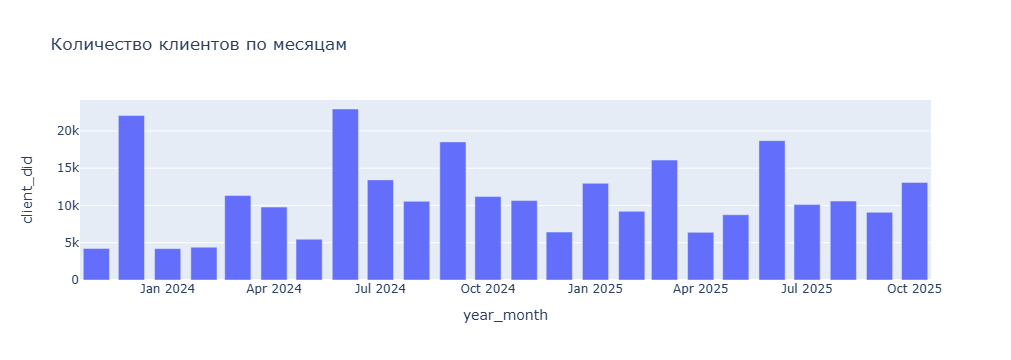

In [15]:
display(sample[sample['year_month'] < '2024-11-01'].pivot_table(values=['client_did'],
                index=['year_month'],
                aggfunc='count',
                margins=False).T)
display(sample[sample['year_month'] >= '2024-11-01'].pivot_table(values=['client_did'],
                index=['year_month'],
                aggfunc='count',
                margins=False).T)

pt = (sample
    .pivot_table(
        values=["client_did"],
        index=["year_month"],
        aggfunc="count",
        margins=False,).reset_index())

fig_sample = px.bar(
    pt,
    x="year_month",
    y="client_did",
    orientation="v",
    title="Количество клиентов по месяцам",
)

fig_sample.show()  # в ноутбуке — опционально

In [16]:
Logger.current_logger().report_plotly(
    title="001 Кол-во клиентов в выборке по месяцам",
    series="",
    figure=fig_sample)

#### Если есть сильный перекос по месяцам - отберем одинаковое количество из каждого месяца - по 10 000

In [ ]:
# sample_new = sample.groupby('report_date', group_keys=False).apply(lambda g: g.sample(n=min(10000, len(g)), random_state=42)).reset_index(drop=True)

In [ ]:
display(sample_new.pivot_table(values=['client_did'],
                index=['report_date'],
                aggfunc='count',
                margins=False).T)
sample_new.pivot_table(values=['client_did'],
                index=['report_date'],
                aggfunc='count',
                margins=False).plot(kind='barh', stacked=True, legend=True, rot=0,
                                    title='Количество клиентов по месяцам'
                                );

### Таргет по месяцам (аналог уровня таргета в классификации)
Среднее и медиана целевой переменной по месяцам — видно тренд и сезонность.

In [17]:
def target_by_month(df, date_col, target_cols, agg="mean", figsize=(12, 4), show=True):
    """График агрегата таргета по месяцам (agg: 'mean' или 'median')."""
    if isinstance(target_cols, str):
        target_cols = [target_cols]

    df = df.copy()
    df["_month"] = df[date_col].dt.to_period("M")
    g = df.groupby("_month", observed=True)[target_cols].agg(agg)

    plot_df = g.reset_index()
    plot_df["_month"] = plot_df["_month"].astype(str)

    fig = px.line(
        plot_df,
        x="_month",
        y=target_cols,
        title=f"Таргет по месяцам ({agg})",
        markers=True,
    )

    fig.update_layout(
        width=int(figsize[0] * 80),
        height=int(figsize[1] * 80),
        yaxis_title=agg,
        legend=dict(
            yanchor="top",
            y=1,
            xanchor="left",
            x=1.02,
        ),
        margin=dict(r=120),
    )
    fig.update_xaxes(tickangle=45)

    if show:
        fig.show()

    return g, fig

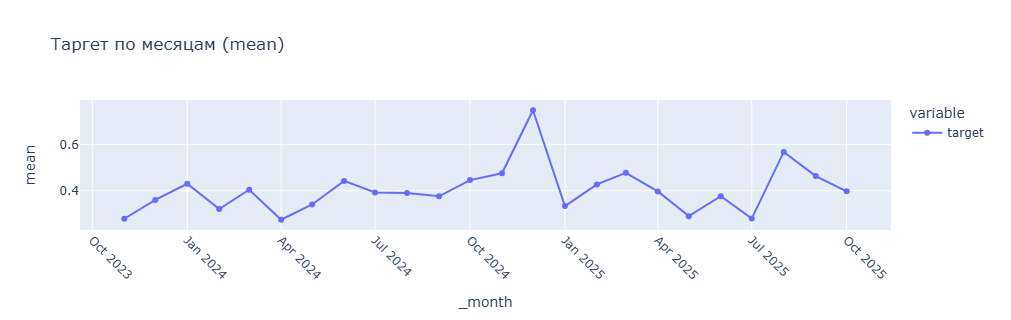

In [18]:
g, fig = target_by_month(sample, "report_date", TARGET, agg="mean")

In [19]:
Logger.current_logger().report_plotly(
    title="002 Таргет по месяцам",
    series="",
    figure=fig,
)

### Распределение таргета
Гистограмма и ящик с усами — асимметрия, выбросы, нули.

In [20]:
from plotly.subplots import make_subplots

In [21]:
def _target_grid(n, ncols):
    nrows = (n + ncols - 1) // ncols
    return nrows, ncols


def _default_figsize(ncols_plot, nrows, aspect=1.2):
    return (4 * ncols_plot, max(4, 3 * nrows * aspect))


def target_histogram(
    df,
    target_cols,
    ncols=2,
    log_scale=False,
    bins=30,
    figsize=None,
    show=True,
):
    """Гистограммы по списку таргетов (отдельная фигура для ClearML)."""
    if isinstance(target_cols, str):
        target_cols = [target_cols]

    n = len(target_cols)
    nrows, ncols_grid = _target_grid(n, ncols)

    if figsize is None:
        figsize = _default_figsize(ncols, nrows)

    fig = make_subplots(
        rows=nrows,
        cols=ncols_grid,
        subplot_titles=list(target_cols),
        horizontal_spacing=0.1,
        vertical_spacing=0.15 if nrows > 1 else 0.12,
    )

    for i, col in enumerate(target_cols):
        r = i // ncols + 1
        c = i % ncols + 1

        x = df[col].dropna().astype(float)
        x_hist = np.log1p(x) if log_scale and x.max() > 0 else x

        counts, edges = np.histogram(x_hist, bins=bins)
        centers = (edges[:-1] + edges[1:]) / 2
        widths = np.diff(edges)

        fig.add_trace(
            go.Bar(
                x=centers,
                y=counts,
                width=widths,
                marker=dict(line=dict(color="black", width=0.5)),
                opacity=0.7,
                showlegend=False,
                name=col,
                hovertemplate="значение: %{x:.4g}<br>число: %{y}<extra></extra>",
            ),
            row=r,
            col=c,
        )

    fig.update_layout(
        width=int(figsize[0] * 80),
        height=int(figsize[1] * 80),
        autosize=False,
        title_text="Гистограмма таргета",
        margin=dict(l=50, r=30, t=70, b=50),
        bargap=0,
    )

    if show:
        fig.show()
    return fig

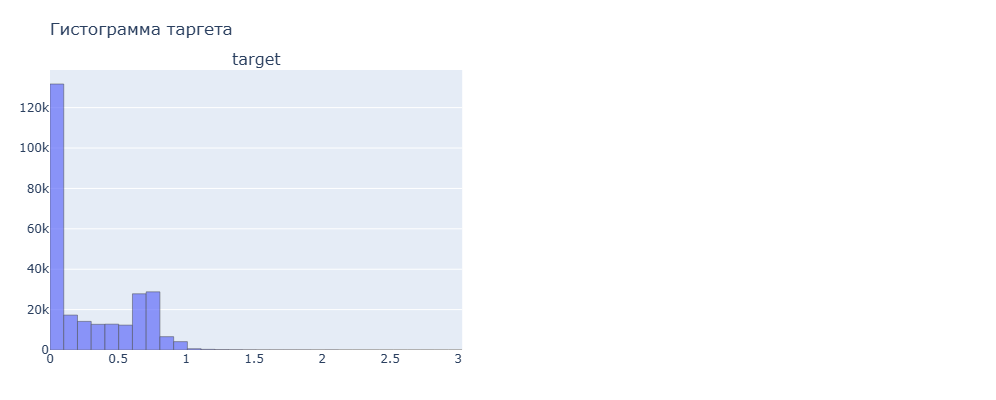

In [22]:
fig_hist = target_histogram(sample, [TARGET], log_scale=True, figsize=(10, 5), show=True)

In [23]:
Logger.current_logger().report_plotly(
    title="003 Распределение таргета",
    series="",
    figure=fig_hist,
)

In [24]:
def target_boxplot(
    df,
    target_cols,
    ncols=2,
    figsize=None,
    show=True,
):
    if isinstance(target_cols, str):
        target_cols = [target_cols]
    n = len(target_cols)
    nrows, ncols_grid = _target_grid(n, ncols)
    if figsize is None:
        figsize = (3 * ncols_grid, max(3.5, 3 * nrows))
    fig, axes = plt.subplots(nrows, ncols_grid, figsize=figsize, squeeze=False)
    for i, col in enumerate(target_cols):
        r, c = i // ncols, i % ncols
        x = df[col].dropna().astype(float)
        axes[r, c].boxplot(x, vert=False)
        axes[r, c].set_title(f"{col} (box)")
        axes[r, c].set_xlabel(col)
    for j in range(n, nrows * ncols_grid):
        axes.flat[j].set_visible(False)
    fig.suptitle("Boxplot таргета", y=1.02)
    plt.tight_layout()
    if show:
        plt.show()
    return fig

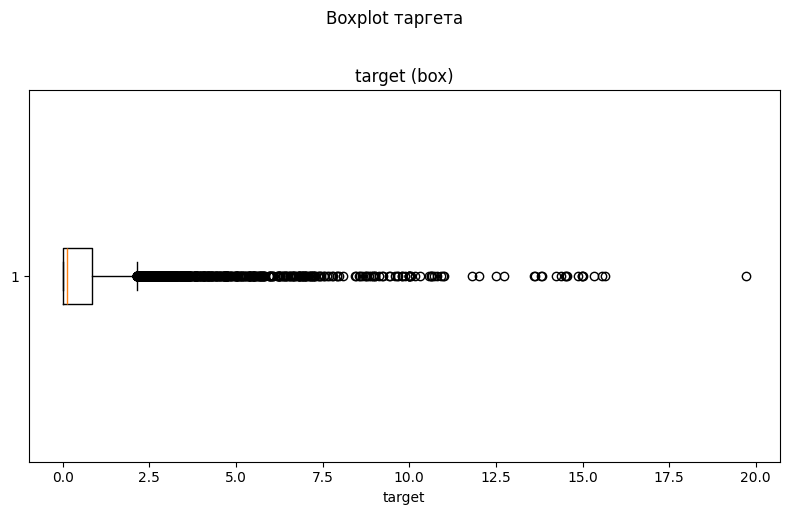

In [25]:
fig_box = target_boxplot(sample, [TARGET], ncols=1, figsize=(8, 5), show=True)

In [26]:
Logger.current_logger().report_matplotlib_figure(
    title="004 Boxplot таргет",
    series="",
    figure=fig_box,
    iteration=0,
)

### Сводка по таргетам: среднее, медиана, std, доля нулей
Таблица — общая и при необходимости по месяцам.

In [27]:
def target_summary(df, target_cols, by_month=False, date_col=None):
    """Таблица: count, mean, median, std, min, max, доля нулей. by_month=True — то же по месяцам."""
    df = df.copy()
    df[target_cols] = df[target_cols].astype(float)
    if by_month and date_col:   
        df["_month"] = df[date_col].dt.to_period("M")
        return df.groupby("_month")[target_cols].agg(
            ["count", "mean", "median", "std", "min", "max"]
        ).round(2)
    res = df[target_cols].agg(["count", "mean", "median", "std", "min", "max"]).T
    res["pct_zero"] = (df[target_cols] == 0).mean() * 100
    return res.round(2)

In [28]:
target_summary(sample, [TARGET])

,count,mean,median,std,min,max,pct_zero
target,270110.0,0.4,0.13,0.54,0.0,19.71,35.41


In [29]:
tbl = target_summary(sample, [TARGET], by_month=True, date_col='report_date')

In [30]:
tbl = tbl.T.droplevel(0).rename_axis("metric").reset_index()
tbl.columns.name = None
tbl.columns = [str(c) for c in tbl.columns]
tbl

,metric,2023-11,2023-12,2024-01,2024-02,2024-03,2024-04,2024-05,2024-06,2024-07,...,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10
0,count,4229.00,22064.00,4210.00,4396.00,11331.00,9779.00,5470.00,22933.00,13430.00,...,12970.00,9212.00,16085.00,6391.00,8752.00,18694.00,10111.00,10594.00,9078.00,13083.00
1,mean,0.28,0.36,0.43,0.32,0.40,0.27,0.34,0.44,0.39,...,0.33,0.43,0.48,0.40,0.29,0.38,0.28,0.57,0.46,0.40
2,median,0.04,0.12,0.14,0.06,0.12,0.03,0.05,0.20,0.07,...,0.04,0.18,0.25,0.08,0.02,0.10,0.01,0.47,0.24,0.21
3,std,0.49,0.50,0.56,0.50,0.55,0.45,0.49,0.53,0.55,...,0.51,0.49,0.63,0.59,0.45,0.48,0.43,0.61,0.52,0.43
4,min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
5,max,13.82,14.98,9.11,9.66,15.00,10.70,7.91,9.44,9.80,...,14.86,4.74,19.71,14.53,8.96,10.06,5.19,14.39,6.42,2.74


In [31]:
Logger.current_logger().report_table(
    title="005 Размер выбороки/статистика по таргету",
    series=" ",
    table_plot=tbl
)

In [109]:
tbl.T.to_excel('check.xlsx')

2026-05-25 13:12:09,975 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.2b1dc8452d524f27bb771f96b83e549a/artifacts/notebook preview/notebook_2b1dc8452d524f27bb771f96b83e549a.html to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>



In [111]:
sample['report_date'].unique()

<DatetimeArray>
['2024-05-23 00:00:00', '2023-12-21 00:00:00', '2024-04-25 00:00:00',
 '2024-06-25 00:00:00', '2023-12-26 00:00:00', '2024-06-11 00:00:00',
 '2024-09-19 00:00:00', '2024-09-16 00:00:00', '2024-02-27 00:00:00',
 '2025-02-25 00:00:00', '2024-11-25 00:00:00', '2024-01-24 00:00:00',
 '2024-08-22 00:00:00', '2024-07-24 00:00:00', '2024-06-13 00:00:00',
 '2023-12-17 00:00:00', '2024-03-13 00:00:00', '2023-11-20 00:00:00',
 '2024-09-25 00:00:00', '2025-01-23 00:00:00', '2024-07-31 00:00:00',
 '2025-04-23 00:00:00', '2024-06-26 00:00:00', '2024-10-30 00:00:00',
 '2024-03-26 00:00:00', '2024-03-22 00:00:00', '2024-06-24 00:00:00',
 '2024-06-20 00:00:00', '2024-11-02 00:00:00', '2025-03-20 00:00:00',
 '2025-05-20 00:00:00', '2024-01-30 00:00:00', '2024-11-19 00:00:00',
 '2024-12-24 00:00:00', '2024-12-26 00:00:00', '2024-10-31 00:00:00',
 '2024-07-30 00:00:00', '2024-12-23 00:00:00', '2024-05-21 00:00:00',
 '2024-05-17 00:00:00', '2025-03-27 00:00:00', '2024-09-13 00:00:00',
 '20

2026-05-26 13:11:19,697 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.2b1dc8452d524f27bb771f96b83e549a/artifacts/notebook preview/notebook_2b1dc8452d524f27bb771f96b83e549a.html to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>

2026-05-26 13:13:38,015 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.2b1dc8452d524f27bb771f96b83e549a/artifacts/notebook preview/notebook_2b1dc8452d524f27bb771f96b83e549a.html to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>

2026-05-26 13:17:41,028 - clearml.st

## 5. Собираем ВДР и фичи вместе

In [32]:
merged_df = sample.copy() 

In [33]:
%%time

MISSING_THRESHOLD = 0.8  # Доля пропусков не более чем

for feat_df, filename in tqdm.tqdm(zip(df_features_lst, filenames), total=len(df_features_lst)):
    duplicates = feat_df[feat_df.duplicated(subset=PRIMARY_KEY, keep=False)]
    diff_cols = (duplicates
                .groupby(PRIMARY_KEY)
                .nunique()
                .gt(1)
                .any(axis=0))
    res = diff_cols[diff_cols].index.tolist()
    feat_df = feat_df.drop(res, axis=1)
    feat_df = feat_df.drop_duplicates(subset=PRIMARY_KEY, keep='first')
    
    missing_df = preprocessing.analyze_missing_values(feat_df, missing_threshold=MISSING_THRESHOLD)
    if missing_df is not None and not missing_df.empty:
        missing_df.to_excel(f'{REPORTS_FOLDER}/{filename}_missing.xlsx')
        feat_df = preprocessing.remove_columns_by_missing(feat_df, missing_df, 0.8)
    
    merged_df = pd.merge(merged_df, feat_df, on=PRIMARY_KEY, how='left')

 21%|██▏       | 6/28 [00:11<00:40,  1.84s/it]

Нет колонок с пропусками > 80.0%


 25%|██▌       | 7/28 [00:12<00:32,  1.53s/it]

Нет колонок с пропусками > 80.0%


 32%|███▏      | 9/28 [00:17<00:41,  2.17s/it]

...

Нет колонок с пропусками > 80.0%


 93%|█████████▎| 26/28 [01:31<00:14,  7.01s/it]

Нет колонок с пропусками > 80.0%


100%|██████████| 28/28 [01:42<00:00,  3.67s/it]

CPU times: user 1min, sys: 42.6 s, total: 1min 42s
Wall time: 1min 42s


In [34]:
# Чистим RAM
del df_features_lst
gc.collect()

63739

In [35]:
merged_df.info()
merged_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270200 entries, 0 to 270199
Columns: 5239 entries, client_did to transaction_cash_trans_avg_cnt_6m_to_total_6m
dtypes: category(39), datetime64[ns](2), float16(2706), float32(1889), float64(478), int16(13), int32(23), int64(2), int8(85), object(2)
memory usage: 4.3+ GB


(270200, 5239)

In [36]:
merged_df = merged_df.dropna(subset=[TARGET])

In [37]:
merged_df.drop(columns=TECH_COLS, inplace=True, errors="ignore")
merged_df = merged_df.drop_duplicates()

In [38]:
merged_df.drop(['current_debt_amt'], axis=1, inplace=True)

In [39]:
merged_df.shape

(270110, 5234)

In [40]:
display(merged_df.columns[:10])
all_features = merged_df.columns[4:] # Список всех доступных фичей

Index(['client_did', 'report_date', 'new_limit', 'target', 'year_month',
       'card_card_uid_aggcnt', 'card_card_uid_by_status_card_nm_aggcnt',
       'card_card_card_uid_by_status_card_nm_aggcnt_div_card_card_uid_aggcnt',
       'card_auto_reissue_flg_by_status_card_nm_aggmax',
       'card_ozc_flg_by_status_card_nm_aggmax'],
      dtype='object')

### Проверка

In [41]:
# Обязательно! Проверка что нет дублей по PRIMARY_KEY
assert merged_df[PRIMARY_KEY].drop_duplicates().shape[0] == merged_df[PRIMARY_KEY].shape[0]

In [42]:
# Если есть дубли - выведем столбцы с ними
duplicates = merged_df[merged_df.duplicated(subset=PRIMARY_KEY, keep=False)]
diff_cols = (duplicates
            .groupby(PRIMARY_KEY)
            .nunique()
            .gt(1)
            .any(axis=0))
res = diff_cols[diff_cols].index.tolist()
print(res)

[]


In [43]:
display(merged_df.shape)
display(merged_df.head(3))

(270110, 5234)

,client_did,report_date,new_limit,target,year_month,card_card_uid_aggcnt,card_card_uid_by_status_card_nm_aggcnt,card_card_card_uid_by_status_card_nm_aggcnt_div_card_card_uid_aggcnt,card_auto_reissue_flg_by_status_card_nm_aggmax,card_ozc_flg_by_status_card_nm_aggmax,...,transaction_cash_trans_sum_3m_to_total_3m,transaction_cash_trans_cnt_3m_to_total_6m,transaction_cash_trans_sum_3m_to_total_6m,transaction_cash_trans_cnt_6m_to_total_6m,transaction_cash_trans_sum_6m_to_total_6m,transaction_cash_trans_avg_cnt_3m_to_6m,transaction_cash_trans_avg_cnt_3m_to_total_3m,transaction_cash_trans_avg_cnt_3m_to_total_6m,transaction_cash_trans_avg_sum_6m_to_total_6m,transaction_cash_trans_avg_cnt_6m_to_total_6m
0,20127190033,2024-05-23,800000,0E-46,2024-05-01,1,1,1.0,1,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20117845254,2023-12-21,90000,0.0883974444444444444444444444444444444444000000,2023-12-01,1,1,1.0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1171690331,2024-04-25,180000,0.0514150555555555555555555555555555555556000000,2024-04-01,6,3,0.5,1,1,...,0.052979,0.009804,0.029602,0.013069,0.033203,1.5,0.016388,0.019608,1.169922,0.013069


## 6. Отбор фичей (однофакторный анализ)


1. Убираем фичи с большой долей пропущенных значений
2. Убираем константные фичи
3. Убираем нестабильные фичи (`PSI > threshold`)
4. Разбиение на сегменты: TRAIN, TEST, OOT
5. Грубый отбор фичей (Оставляем ТОП-N фичей)

### 6.1 Убираем фичи с большой долей пропусков

In [44]:
MISSING_THRESHOLD = 0.8  # Доля пропусков не более чем

missing_df = preprocessing.analyze_missing_values(merged_df, missing_threshold=MISSING_THRESHOLD)
missing_df.to_excel(f'{REPORTS_FOLDER}/missing_percentage.xlsx')

In [45]:
merged_df = preprocessing.remove_columns_by_missing(merged_df, missing_df, 0.8)

In [46]:
merged_df.shape

(270110, 4294)

### 6.2 Убираем фичи с константными значениями (низкая дисперсия данных)

In [47]:
res = preprocessing.find_constant_features(merged_df, threshold=0.95, verbose=False)
res['constant']

['contract_dep_contract_uid_by_status_nm_arrest_aggmax',
 'dbo_dpasp_change_card_limit_reject_flg_m12',
 'dbo_dpasp_change_card_limit_reject_aggsum_m12',
 'dbo_dpasp_change_card_limit_reject_flg_m6',
 'dbo_dpasp_change_card_limit_reject_aggsum_m6',
 'dbo_dpasp_change_card_limit_reject_flg_m3',
 'dbo_dpasp_change_limit_plan_reject_flg_m3',
 'dbo_dpasp_change_card_limit_reject_aggsum_m3',
 'dbo_dpasp_change_limit_plan_reject_aggsum_m3',
 'dbo_dpasp_change_limit_plan_flg_m1',
 'dbo_client_authorize_aggsum_d1',
 'dbo_client_authorize_success_aggsum_d1',
 'dbo_client_authorize_fail_aggsum_d1',
 'dbo_client_authorize_mb_aggsum_d1',
 'dbo_client_authorize_mb_success_aggsum_d1',
 'dbo_client_authorize_mb_fail_aggsum_d1',
 'dbo_client_authorize_web_aggsum_d1',
 'dbo_client_authorize_web_success_aggsum_d1',
 'dbo_client_authorize_web_fail_aggsum_d1',
 'dbo_client_authorize_psw_aggsum_d1',
 'dbo_client_authorize_psw_success_aggsum_d1',
 'dbo_client_authorize_psw_fail_aggsum_d1',
 'dbo_client_auth

In [48]:
to_drop  = [col for col in merged_df.columns if merged_df[col].nunique() == 1 and col not in [TIME_COL, 'year_month']]
merged_df.drop(to_drop, axis = 1, inplace =True)

In [49]:
merged_df.shape

(270110, 4127)

### 6.3 Отбор по PSI

In [50]:
features = list(merged_df.drop(['report_date', 'client_did', 'new_limit', 'year_month'] +[TARGET], axis=1).columns)

In [51]:
features

['card_card_uid_aggcnt',
 'card_card_uid_by_status_card_nm_aggcnt',
 'card_card_card_uid_by_status_card_nm_aggcnt_div_card_card_uid_aggcnt',
 'card_auto_reissue_flg_by_status_card_nm_aggmax',
 'card_ozc_flg_by_status_card_nm_aggmax',
 'card_is_digital_by_status_card_nm_aggmax',
 'card_izp_flg_by_status_card_nm_aggmax',
 'card_report_date_diff_card_close_dt_aggmin',
 'card_report_date_diff_card_close_dt_aggmax',
 'card_report_date_diff_card_close_dt_aggavg',
 'card_card_exp_dt_diff_report_date_aggmin',
 'card_card_exp_dt_diff_report_date_aggmax',
 'card_card_exp_dt_diff_report_date_aggavg',
 'card_report_date_diff_card_work_dt_aggmax',
 'card_report_date_diff_card_work_dt_aggavg',
 'card_work_diff_start_aggmin_d730',
 'card_work_diff_start_aggmax_d730',
 'card_work_diff_start_aggavg_d730',
 'card_work_diff_start_aggmin_d365',
 'card_work_diff_start_aggmax_d365',
 'card_work_diff_start_aggavg_d365',
 'card_sms_status_code_aggmax',
 'card_sms_end_diff_sms_start_aggmin_d730',
 'card_sms_en

In [52]:
%%time
psi_result = preprocessing.calculate_feat_psi(merged_df[list(features) + ['year_month']], features, date_col='year_month')

CPU times: user 9min 43s, sys: 3.95 s, total: 9min 47s
Wall time: 9min 52s


In [53]:
psi_result.head(20)

,card_card_uid_aggcnt,card_card_uid_by_status_card_nm_aggcnt,card_card_card_uid_by_status_card_nm_aggcnt_div_card_card_uid_aggcnt,card_auto_reissue_flg_by_status_card_nm_aggmax,card_ozc_flg_by_status_card_nm_aggmax,card_is_digital_by_status_card_nm_aggmax,card_izp_flg_by_status_card_nm_aggmax,card_report_date_diff_card_close_dt_aggmin,card_report_date_diff_card_close_dt_aggmax,card_report_date_diff_card_close_dt_aggavg,...,transaction_cash_trans_sum_3m_to_total_3m,transaction_cash_trans_cnt_3m_to_total_6m,transaction_cash_trans_sum_3m_to_total_6m,transaction_cash_trans_cnt_6m_to_total_6m,transaction_cash_trans_sum_6m_to_total_6m,transaction_cash_trans_avg_cnt_3m_to_6m,transaction_cash_trans_avg_cnt_3m_to_total_3m,transaction_cash_trans_avg_cnt_3m_to_total_6m,transaction_cash_trans_avg_sum_6m_to_total_6m,transaction_cash_trans_avg_cnt_6m_to_total_6m
date,,,,,,,,,,,,,,,,,,,,,
2023-11-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2023-12-01,0.018576,0.005050,0.031846,0.013027,0.004962,0.0,0.0,0.038092,0.061985,0.023465,...,0.002286,0.001916,0.002843,0.002712,0.003059,0.002081,0.002268,0.001916,0.003665,0.002712
2024-01-01,0.147834,0.003503,0.167301,0.081800,0.013929,0.0,0.0,0.257225,0.203017,0.179600,...,0.005098,0.005809,0.005838,0.007407,0.011111,0.007639,0.004614,0.005809,0.018813,0.007407
2024-02-01,0.071627,0.001584,0.098901,0.156461,0.000754,0.0,0.0,0.143203,0.130496,0.099519,...,0.001685,0.004793,0.005605,0.008126,0.010127,0.004424,0.002129,0.004793,0.012955,0.008126
2024-03-01,0.090451,0.002257,0.114284,0.108781,0.002349,0.0,0.0,0.171324,0.138200,0.109270,...,0.009029,0.009608,0.009869,0.012653,0.014406,0.014377,0.009491,0.009608,0.019864,0.012653
2024-04-01,0.047411,0.000584,0.056785,0.095860,0.003487,0.0,0.0,0.132153,0.099056,0.069084,...,0.004881,0.007528,0.009570,0.015341,0.010937,0.021623,0.004002,0.007528,0.020143,0.015341
2024-05-01,0.140182,0.005389,0.167340,0.227972,0.001168,0.0,0.0,0.229884,0.194293,0.181444,...,0.018990,0.029438,0.028284,0.027940,0.027759,0.020141,0.018763,0.029438,0.023958,0.027940
2024-06-01,0.081003,0.000564,0.108685,0.102414,0.000144,0.0,0.0,0.231111,0.122615,0.121287,...,0.018029,0.024697,0.025141,0.029592,0.031527,0.039822,0.017920,0.024697,0.040427,0.029592
2024-07-01,0.128209,0.321120,0.127487,0.191032,0.002110,0.0,0.0,0.240490,0.165246,0.171064,...,0.056517,0.062230,0.061831,0.064214,0.067340,0.054302,0.055715,0.062230,0.056667,0.064214


In [ ]:
%%time
psi_result = preprocessing.calculate_feat_psi(merged_df[list(features) + ['report_date']], features, date_col='report_date')

In [112]:
# === 1. Агрегат PSI по каждой дате (все фичи) ===
# Ищем month, когда «плохой» PSI сразу у многих фичей — возможная смена условий выборки

PSI_DATE_THRESHOLDS = [0.10, 0.15, 0.25]

psi = psi_result.copy()
psi.index = pd.to_datetime(psi.index)
psi.index.name = "date"

# первый month — обычно база для PSI (значения ~0), в аномалиях не участвует
psi_calc = psi.iloc[1:].copy()

date_stats = pd.DataFrame(index=psi_calc.index)
date_stats.index.name = "date"

arr = psi_calc.to_numpy(dtype=float)
date_stats["n_features"] = psi_calc.shape[1]
date_stats["psi_median"] = np.nanmedian(arr, axis=1)
date_stats["psi_mean"] = np.nanmean(arr, axis=1)
date_stats["psi_p90"] = np.nanpercentile(arr, 90, axis=1)
date_stats["psi_max"] = np.nanmax(arr, axis=1)

for thr in PSI_DATE_THRESHOLDS:
    date_stats[f"share_psi_gt_{thr:.2f}"] = (psi_calc > thr).mean(axis=1)
    date_stats[f"n_psi_gt_{thr:.2f}"] = (psi_calc > thr).sum(axis=1)

print("Топ дат по доле фичей с PSI > 0.15:")
display(date_stats.sort_values("share_psi_gt_0.15", ascending=False).round(4).head(15))

Топ дат по доле фичей с PSI > 0.15:


,n_features,psi_median,psi_mean,psi_p90,psi_max,share_psi_gt_0.10,n_psi_gt_0.10,share_psi_gt_0.15,n_psi_gt_0.15,share_psi_gt_0.25,n_psi_gt_0.25
date,,,,,,,,,,,
2025-08-01,4122,0.1190,0.2367,0.4796,13.1276,0.6218,2563,0.4030,1661,0.2521,1039
2025-07-01,4122,0.0911,0.1993,0.3711,14.0494,0.4840,1995,0.3661,1509,0.1788,737
2024-12-01,4122,0.0997,0.1913,0.4209,10.6532,0.4985,2055,0.3433,1415,0.2135,880
2025-09-01,4122,0.0916,0.1995,0.4003,10.8610,0.4641,1913,0.3239,1335,0.1965,810
2025-04-01,4122,0.0948,0.2090,0.4199,15.8983,0.4736,1952,0.2853,1176,0.1754,723
2025-10-01,4122,0.0753,0.1577,0.3216,9.4521,0.4129,1702,0.2717,1120,0.1608,663
2025-03-01,4122,0.0853,0.1849,0.3422,16.9411,0.4403,1815,0.2436,1004,0.1361,561
2024-11-01,4122,0.0721,0.1516,0.3555,11.4786,0.3671,1513,0.2402,990,0.1395,575
2025-06-01,4122,0.0708,0.1630,0.3425,14.1514,0.3362,1386,0.2244,925,0.1305,538


In [113]:
# === 2. Подозрительные даты (robust z-score по системной метрике) ===

METRIC = "share_psi_gt_0.15"   # можно: psi_median, psi_p90, share_psi_gt_0.10
Z_THRESH = 2.5
MIN_SHARE = 0.03               # отсечь месяцы, где «всплеск» у крошечной доли фичей

s = date_stats[METRIC]
med = s.median()
mad = np.median(np.abs(s - med))
date_stats["robust_z"] = 0.6745 * (s - med) / mad if mad > 0 else 0.0
date_stats["is_suspicious"] = (date_stats["robust_z"].abs() >= Z_THRESH) & (s >= MIN_SHARE)

# скачок относительно предыдущего month
date_stats["delta_share_0.15"] = date_stats["share_psi_gt_0.15"].diff()
date_stats["delta_psi_median"] = date_stats["psi_median"].diff()

suspicious_dates = date_stats[date_stats["is_suspicious"]].sort_values(METRIC, ascending=False)
print(f"Подозрительных дат (robust z): {len(suspicious_dates)}")
display(suspicious_dates.round(4))

print("\nТоп скачков share PSI>0.15 vs прошлый month:")
display(
    date_stats.sort_values("delta_share_0.15", ascending=False)[
        ["share_psi_gt_0.15", "delta_share_0.15", "psi_median", "n_features"]
    ].round(4).head(10)
)


Подозрительных дат (robust z): 0


,n_features,psi_median,psi_mean,psi_p90,psi_max,share_psi_gt_0.10,n_psi_gt_0.10,share_psi_gt_0.15,n_psi_gt_0.15,share_psi_gt_0.25,n_psi_gt_0.25,robust_z,is_suspicious,delta_share_0.15,delta_psi_median
date,,,,,,,,,,,,,,,



Топ скачков share PSI>0.15 vs прошлый month:


,share_psi_gt_0.15,delta_share_0.15,psi_median,n_features
date,,,,
2025-07-01,0.3661,0.1417,0.0911,4122
2024-12-01,0.3433,0.1031,0.0997,4122
2024-09-01,0.2103,0.0842,0.0570,4122
2024-11-01,0.2402,0.0633,0.0721,4122
2024-01-01,0.0754,0.0616,0.0318,4122
2024-05-01,0.0902,0.0568,0.0257,4122
2025-04-01,0.2853,0.0417,0.0948,4122
2025-03-01,0.2436,0.0395,0.0853,4122
2025-08-01,0.4030,0.0369,0.1190,4122


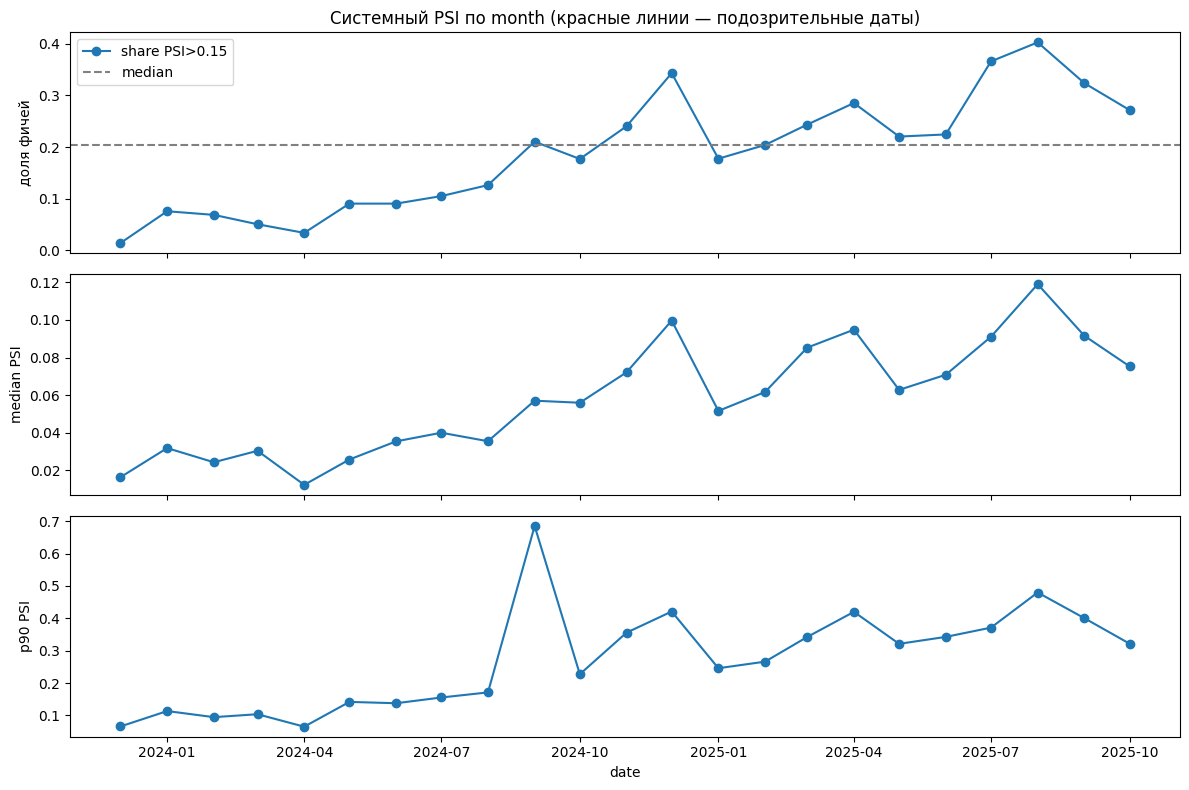

In [114]:
# === 3. График: системный дрейф по датам ===

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(date_stats.index, date_stats["share_psi_gt_0.15"], marker="o", label="share PSI>0.15")
axes[0].axhline(date_stats["share_psi_gt_0.15"].median(), ls="--", color="gray", label="median")
for d in suspicious_dates.index:
    axes[0].axvline(d, color="red", alpha=0.35)
axes[0].set_ylabel("доля фичей")
axes[0].legend(loc="upper left")
axes[0].set_title("Системный PSI по month (красные линии — подозрительные даты)")

axes[1].plot(date_stats.index, date_stats["psi_median"], marker="o")
axes[1].set_ylabel("median PSI")

axes[2].plot(date_stats.index, date_stats["psi_p90"], marker="o")
axes[2].set_ylabel("p90 PSI")
axes[2].set_xlabel("date")

plt.tight_layout()
plt.show()

In [115]:
# === 4. Сверка с объёмом выборки по month ===
# если на дату мало строк — высокий PSI может быть артефактом, а не «сменой условий»

vol = merged_df.groupby("year_month").size().rename("n_rows")
vol.index = pd.to_datetime(vol.index)

date_check = date_stats.join(vol, how="left")
cols_show = ["n_rows", "share_psi_gt_0.15", "psi_median", "psi_p90", "robust_z", "is_suspicious"]
display(date_check[cols_show].sort_values("share_psi_gt_0.15", ascending=False).round(4))

# month с малым N и высоким PSI — проверить вручную
LOW_N = date_check["n_rows"].quantile(0.10)
flag_low_n = date_check[(date_check["n_rows"] <= LOW_N) & (date_check["share_psi_gt_0.15"] > date_check["share_psi_gt_0.15"].median())]
if len(flag_low_n):
    print(f"\nВнимание: высокий PSI при малом N (ниже p10={LOW_N:.0f}):")
    display(flag_low_n[cols_show].round(4))

,n_rows,share_psi_gt_0.15,psi_median,psi_p90,robust_z,is_suspicious
date,,,,,,
2025-08-01,10594,0.4030,0.1190,0.4796,1.3523,False
2025-07-01,10111,0.3661,0.0911,0.3711,1.1016,False
2024-12-01,6428,0.3433,0.0997,0.4209,0.9466,False
2025-09-01,9078,0.3239,0.0916,0.4003,0.8147,False
2025-04-01,6391,0.2853,0.0948,0.4199,0.5525,False
2025-10-01,13083,0.2717,0.0753,0.3216,0.4601,False
2025-03-01,16085,0.2436,0.0853,0.3422,0.2688,False
2024-11-01,10603,0.2402,0.0721,0.3555,0.2457,False
2025-06-01,18694,0.2244,0.0708,0.3425,0.1385,False


In [116]:
# === 5. Детализация по одной дате + оценка эффекта исключения month ===

CHECK_DATE = (
    suspicious_dates.index[0]
    if len(suspicious_dates)
    else date_stats["share_psi_gt_0.15"].idxmax()
)
print(f"Детализация для: {CHECK_DATE.date()}")

psi_one = psi_calc.loc[CHECK_DATE].sort_values(ascending=False)
print(f"Фичей с PSI > 0.15: {(psi_one > 0.15).sum()} / {len(psi_one)}")
display(psi_one[psi_one > 0.15].head(30).to_frame("PSI").round(4))

# --- кандидаты на исключение (правьте список вручную после ячеек 1–4) ---
EXCLUDE_CANDIDATES = list(suspicious_dates.index)   # или, например: [pd.Timestamp("2024-01-01")]

PSI_MAX_FOR_PASS = 0.15   # тот же смысл, что PSI_THRESHOLD ниже по ноутбуку

psi_wo = psi_calc.drop(index=EXCLUDE_CANDIDATES, errors="ignore")
n_pass_if_exclude = (psi_wo.max(axis=0) < PSI_MAX_FOR_PASS).sum()
n_pass_current = (psi_calc.max(axis=0) < PSI_MAX_FOR_PASS).sum()

print(f"\nКандидаты на исключение из merged_df: {[d.strftime('%Y-%m-%d') for d in EXCLUDE_CANDIDATES]}")
print(f"Фичей с max PSI < {PSI_MAX_FOR_PASS}: сейчас {n_pass_current}, если выкинуть month — {n_pass_if_exclude} (из {psi_calc.shape[1]})")
print("Важно: для финального решения пересчитайте psi_result на merged_df без этих month.")

Детализация для: 2025-08-01
Фичей с PSI > 0.15: 1661 / 4122


,PSI
contract_agg_monthly_cred_total_interest_rate_aggmax_12m,13.1276
contract_agg_monthly_cred_cc_total_interest_rate_aggmax_12m,12.0946
crds_cci_min_limit_tariff_aggmax_d720,9.6771
card_limit_report_date_diff_creation_dt_aggmin,9.5562
contract_agg_monthly_cred_total_interest_rate_aggmax_24m,9.5396
contract_agg_monthly_cred_cc_total_interest_rate_aggmax_24m,9.3401
contract_agg_monthly_cred_cc_total_interest_rate_aggavg_12m,7.9144
application_approved_product_by_cardcred_requested_rate_aggmin_d360,6.1610
contract_agg_monthly_cred_total_interest_rate_aggavg_12m,5.1466
application_approved_product_by_cardcred_requested_rate_aggmax_d360,5.0486



Кандидаты на исключение из merged_df: []
Фичей с max PSI < 0.15: сейчас 1636, если выкинуть month — 1636 (из 4122)
Важно: для финального решения пересчитайте psi_result на merged_df без этих month.


In [54]:
# Фильтр 1: глобальное ограничение PSI на всей выборке
PSI_THRESHOLD = 0.15 # Убираем фичи, с PSI > PSI_THRESHOLD
# Фильтр 2: Ограничение тренда
# Если есть линейный тренд на рост PSI, то максимальный тренд PSI не более PSI_TREND
PSI_TREND = 0.05
# PSI_TREND = 0.1

In [55]:
to_del_all = []
for col in psi_result.columns:
    max_psi = psi_result[col].max()
    lrgs = linregress(range(len(psi_result[col])), psi_result[col])
    if ((lrgs.slope > 0) & (lrgs.pvalue < 0.05) & (psi_result[col].max() > PSI_TREND)) or psi_result[col].max() >= PSI_THRESHOLD:
        to_del_all.append(col)

In [56]:
psi_result[to_del_all].to_excel(f'{REPORTS_FOLDER}/psi_to_delete.xlsx')

In [57]:
len(to_del_all), merged_df.shape

(3339, (270110, 4127))

In [58]:
merged_df.drop(to_del_all, axis=1, inplace=True)

In [59]:
merged_df.shape

(270110, 788)

In [60]:
merged_df[TARGET] = merged_df[TARGET].astype(float)

In [61]:
merged_df = merged_df.dropna(subset=[TARGET])

In [62]:
merged_df.shape

(270110, 788)

### 6.4 Разбиение на сегменты: Train test split

Сегменты:
* `train` - Обучающая часть
* `test` - тестовая часть
* `oot` - в зависимости от типа валидации
* `other` - дубли, некорректные записи и тд

In [63]:
df = merged_df[merged_df['report_date'] < '2025.09.01']
oot = merged_df[merged_df['report_date'] >= '2025.09.01']
train = df[df['report_date'] < '2025.07.01']
test = df[df['report_date'] >= '2025.07.01']

In [64]:
train.shape, test.shape, oot.shape

((227244, 788), (20705, 788), (22161, 788))

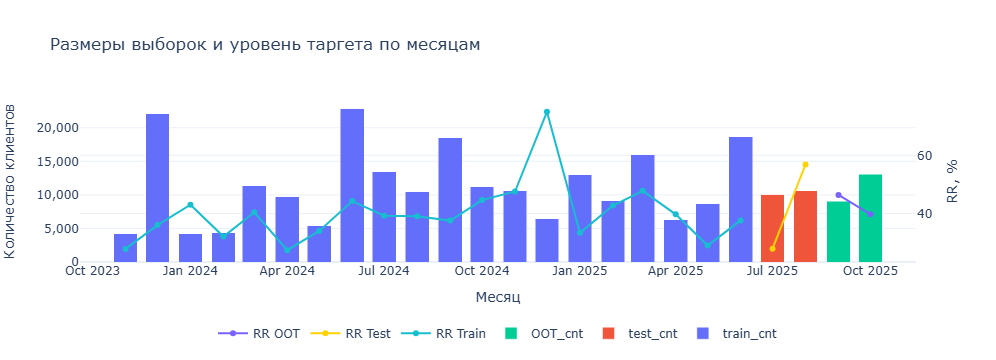

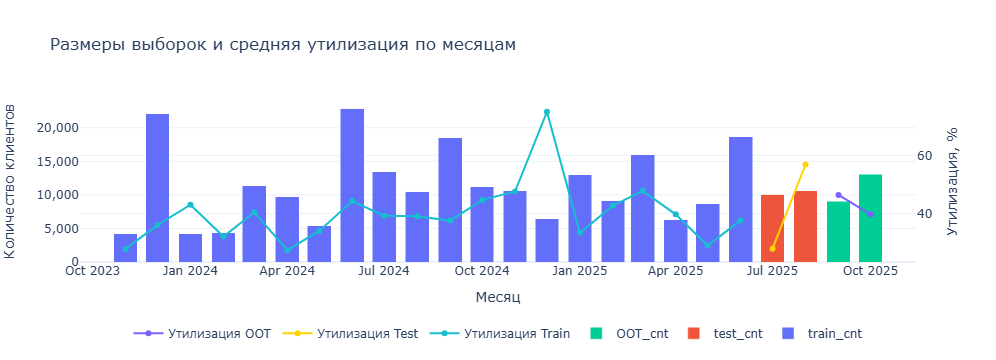

In [65]:
info_df, fig_df = report.counts_target_ratio(train, test, oot, TIME_COL, TARGET)
fig_df.update_layout(
    title="Размеры выборок и средняя утилизация по месяцам",
    yaxis2=dict(title="Утилизация, %", overlaying="y", side="right"),
)
for tr in fig_df.data:
    if tr.name and tr.name.startswith("RR "):
        tr.name = tr.name.replace("RR ", "Утилизация ")

info_df = info_df.rename(columns={
    "rr_train": "util_train",
    "rr_test": "util_test",
    "rr_oot": "util_oot",
})
fig_df

In [66]:
Logger.current_logger().report_plotly(
    title="006 Размеры выборок и средняя утилизация по месяцам",
    series="",
    figure=fig_df)

In [67]:
info_df_to_log = info_df.copy()
info_df_to_log["month"] = pd.to_datetime(info_df_to_log["month"]).dt.strftime("%Y-%m-%d")
Logger.current_logger().report_table(
    title="007 Размеры выборок и средняя утилизация по месяцам",
    series="",
    table_plot=info_df_to_log
)
info_df

,month,train_cnt,test_cnt,oot_cnt,util_train,util_test,util_oot
0,2023-11-01,4229,---,---,27.84%,---,---
1,2023-12-01,22064,---,---,36.01%,---,---
2,2024-01-01,4210,---,---,43.03%,---,---
3,2024-02-01,4396,---,---,32.07%,---,---
4,2024-03-01,11331,---,---,40.42%,---,---
5,2024-04-01,9779,---,---,27.4%,---,---
6,2024-05-01,5470,---,---,34.03%,---,---
7,2024-06-01,22933,---,---,44.27%,---,---
8,2024-07-01,13430,---,---,39.24%,---,---
9,2024-08-01,10554,---,---,39.02%,---,---


In [68]:
# Проверка на потерянные строки 
assert train[PRIMARY_KEY].shape[0] +\
        test[PRIMARY_KEY].shape[0] +\
         oot[PRIMARY_KEY].shape[0] == sample.dropna(subset=[TARGET]).shape[0]

## 7. Предварительный отбор фичей

In [69]:
# Доработать
categorical_features = list(merged_df
                            .drop(columns=PRIMARY_KEY+['year_month',TARGET])
                            .select_dtypes(['category', 'object'])
                            .columns)
numerical_features = list(merged_df
                          .drop(columns=categorical_features + PRIMARY_KEY + ['year_month',TARGET])
                          .columns)

print(f'Categorical: {len(categorical_features)}')
print(f'Numerical: {len(numerical_features)}')

Categorical: 9
Numerical: 775


In [70]:
features = categorical_features + numerical_features

In [71]:
features

['client_cl_category_nm',
 'client_izp_flg',
 'client_call_consent_flg',
 'client_sms_consent_flg',
 'client_messenger_consent_flg',
 'client_email_consent_flg',
 'application_employer_ownership_type',
 'dbo_client_info_status_profile',
 'dbo_client_info_push_flg',
 'new_limit',
 'card_ozc_flg_by_status_card_nm_aggmax',
 'card_is_digital_by_status_card_nm_aggmax',
 'card_izp_flg_by_status_card_nm_aggmax',
 'card_sms_end_diff_sms_start_aggmin_d730',
 'card_sms_end_diff_sms_start_aggmin_d365',
 'card_sms_end_diff_sms_start_aggmin_d180',
 'card_sms_end_diff_sms_start_aggmin_d90',
 'card_sms_end_diff_sms_start_aggmax_d90',
 'card_bm_off_diff_bm_on_aggmin_d730',
 'card_bm_off_diff_bm_on_aggmin_d365',
 'card_bm_off_diff_bm_on_aggmin_d180',
 'card_bm_off_diff_bm_on_aggmin_d90',
 'card_bm_off_diff_bm_on_aggmax_d90',
 'card_spec_offer_code_aggmax_d90',
 'dbo_client_authorize_days_from_last_mb_success_auth',
 'dbo_client_authorize_web_aggsum_m6',
 'dbo_client_authorize_web_aggsum_m3',
 'dbo_clie

## Tweedie

In [72]:
def check_working_model(train, train_pred, test, test_pred, oot, oot_pred):
    y = train["target"].astype(float).values
    y_const = np.full_like(y, y.mean())
    print("MAE const:", mean_absolute_error(y, y_const))
    print("R2 model train :", r2_score(y, train_pred))
    print("R2 model test  :", r2_score(test["target"].astype(float).values, test_pred))
    print("R2 model oot   :", r2_score(oot["target"].astype(float).values, oot_pred))

In [73]:
LGBM_KW_TWEEDIE = dict(
    objective="tweedie",
    tweedie_variance_power=1.5,
)

In [74]:
def select_by_importance(data, target_col, eval_data, max_features=None, importance_threshold=None, random_state=42):
    """
    Важность из LGBMRegressor. Возвращает (selected, imp, model) — model для evaluate_model.
    """
    X = data.drop(columns=[target_col])
    y = data[target_col]
    eval_set = [(eval_data.drop(columns=[target_col]), eval_data[target_col])]
    X_ = X.select_dtypes(include=[np.number]).copy()
    eval_align = [(X_val[X_.columns], y_val) for X_val, y_val in eval_set]
    m = lgb.LGBMRegressor(random_state=random_state, n_estimators=100, max_depth=4, verbosity=-1, **LGBM_KW_TWEEDIE)
    m.fit(X_, y, eval_set=eval_align)
    imp = pd.Series(m.feature_importances_, index=X_.columns).sort_values(ascending=False)
    selected = imp[imp >= importance_threshold].index.tolist() if importance_threshold is not None else imp.index.tolist()
    if max_features is not None:
        selected = imp.head(max_features).index.tolist()
    return selected, imp, m


def evaluate_model(model, train_df, test_df, oot_df, target_col):
    """
    Сводка по модели: Train / Test / OOT. Возвращает DataFrame с колонками:
    Target, AVG target, AVG pred, Dataset, MAPE, MAE, MAE 95%, RMSE, Non Zero.
    MAE 95% — MAE по 95% данных без 5% наибольших значений таргета y (выбросы по y).
    """
    feat = getattr(model, "feature_name_", None) or getattr(model, "feature_names_in_", None)
    if feat is None:
        feat = [c for c in train_df.columns if c != target_col]
    rows = []
    for name, df in [("Train", train_df), ("Test", test_df), ("OOT", oot_df)]:
        X = df[feat] if all(c in df.columns for c in feat) else df.drop(columns=[target_col])
        y = df[target_col].values
        pred = model.predict(X)
        nz = (y != 0)
        mape = np.mean(np.abs((y - pred)[nz]) / y[nz]) if nz.sum() > 0 else np.nan
        mae = np.mean(np.abs(y - pred))
        thresh_y = np.percentile(y, 95)
        mask = y <= thresh_y
        mae_95 = np.mean(np.abs(y[mask] - pred[mask])) if mask.sum() > 0 else np.nan
        rmse = np.sqrt(np.mean((y - pred) ** 2))
        rows.append({
            "Target": target_col,
            "AVG target": y.mean(),
            "AVG pred": pred.mean(),
            "Dataset": name,
            # "MAPE": mape,
            "MAE": mae,
            "MAE 95%": mae_95,
            "RMSE": rmse,
            "Non Zero": int(nz.sum()),
        })
    return pd.DataFrame(rows)

In [75]:
def metric_vs_n_features(data, target_col, eval_data, imp, step=30, metric="rmse", random_state=42, threshold=0.005):
    """
    Перебор числа признаков по важности: от 20 с шагом step до n_all. imp — результат select_by_importance.
    threshold: порог — берётся наименьшее n, при котором метрика <= минимум * (1 + threshold). Например 0.005 = 0.5%.
    Если None — просто argmin. Возвращает (report_df, best_n, selected, model).
    """
    MIN_FEATURES = 20
    n_all = len(imp)
    start = min(MIN_FEATURES, n_all)
    n_features_list = list(range(start, n_all + 1, step))
    if n_all not in n_features_list:
        n_features_list.append(n_all)
    n_features_list = sorted(set(n_features_list))

    X_ev = eval_data[imp.index.tolist()]
    y_ev = eval_data[target_col].values
    fn = mean_squared_error if metric == "rmse" else mean_absolute_error

    rows = []
    for n in n_features_list:
        cols = imp.head(n).index.tolist()
        X_tr = data[cols]
        y_tr = data[target_col]
        m = lgb.LGBMRegressor(random_state=random_state, n_estimators=100, max_depth=4, verbosity=-1, **LGBM_KW_TWEEDIE)
        m.fit(X_tr, y_tr, eval_set=[(X_ev[cols], y_ev)])
        pred = m.predict(X_ev[cols])
        val = np.sqrt(fn(y_ev, pred)) if metric == "rmse" else fn(y_ev, pred)
        rows.append({"n_features": n, "metric_value": val})

    report_df = pd.DataFrame(rows)
    best_metric = report_df["metric_value"].min()
    if threshold is not None:
        metric_limit = best_metric * (1 + threshold)
        candidates = report_df[report_df["metric_value"] <= metric_limit].sort_values("n_features")
        best_n = int(candidates.iloc[0]["n_features"]) if len(candidates) > 0 else int(report_df.loc[report_df["metric_value"].idxmin(), "n_features"])
    else:
        best_n = int(report_df.loc[report_df["metric_value"].idxmin(), "n_features"])
    selected = imp.head(best_n).index.tolist()
    model = lgb.LGBMRegressor(random_state=random_state, n_estimators=100, max_depth=4, verbosity=-1, **LGBM_KW_TWEEDIE)
    model.fit(data[selected], data[target_col], eval_set=[(eval_data[selected], eval_data[target_col])])

    plt.figure(figsize=(8, 4))
    plt.plot(report_df["n_features"], report_df["metric_value"], marker="o")
    plt.axvline(best_n, color="gray", linestyle="--", label=f"best n={best_n}")
    plt.xlabel("Число признаков")
    plt.ylabel(metric.upper())
    plt.title(f"Метрика на eval от n для {target_col}")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    return report_df, best_n, selected, model

In [76]:
def tune_hyperparams(data, target_col, eval_data, max_evals=30, metric="rmse", random_state=42):
    """
    Подбор гиперпараметров LGBM через Hyperopt (TPE). 
    Возвращает (best_model, best_params).
    """
    X = data.drop(columns=[target_col])
    y = data[target_col]
    X_ev = eval_data.drop(columns=[target_col])
    y_ev = eval_data[target_col].values
    fn = mean_squared_error if metric == "rmse" else mean_absolute_error

    space = {
        "n_estimators": hp.quniform("n_estimators", 50, 300, 25),
        "max_depth": hp.quniform("max_depth", 3, 10, 1),
        "learning_rate": hp.loguniform("learning_rate", np.log(0.02), np.log(0.3)),
        "num_leaves": hp.quniform("num_leaves", 15, 127, 10),
        "min_child_samples": hp.quniform("min_child_samples", 5, 50, 5),
        "tweedie_variance_power": hp.uniform("tweedie_variance_power", 1.2, 1.8),
    }

    def objective(params):
        p = {
            "n_estimators": int(params["n_estimators"]),
            "max_depth": int(params["max_depth"]),
            "learning_rate": params["learning_rate"],
            "num_leaves": int(params["num_leaves"]),
            "min_child_samples": int(params["min_child_samples"]),
            "objective": "tweedie",
            "tweedie_variance_power": params["tweedie_variance_power"],
        }
        m = lgb.LGBMRegressor(random_state=random_state, verbosity=-1, **p)
        m.fit(X, y, eval_set=[(X_ev, y_ev)])
        pred = m.predict(X_ev)
        score = np.sqrt(fn(y_ev, pred)) if metric == "rmse" else fn(y_ev, pred)
        return {"loss": score, "status": STATUS_OK}

    trials = Trials()
    best = fmin(
        objective, space, algo=tpe.suggest, max_evals=max_evals, trials=trials,
        rstate=np.random.default_rng(random_state),
    )
    best_params = {
        "n_estimators": int(best["n_estimators"]),
        "max_depth": int(best["max_depth"]),
        "learning_rate": best["learning_rate"],
        "num_leaves": int(best["num_leaves"]),
        "min_child_samples": int(best["min_child_samples"]),
        "objective": "tweedie",
        "tweedie_variance_power": best["tweedie_variance_power"],
    }
    best_model = lgb.LGBMRegressor(random_state=random_state, verbosity=-1, **best_params)
    best_model.fit(X, y, eval_set=[(X_ev, y_ev)])
    return best_model, best_params

/opt/conda/lib/python3.11/site-packages/clearml/utilities/plotlympl/mplexporter/exporter.py:101: UserWarning:

Blended transforms not yet supported. Zoom behavior may not work as expected.



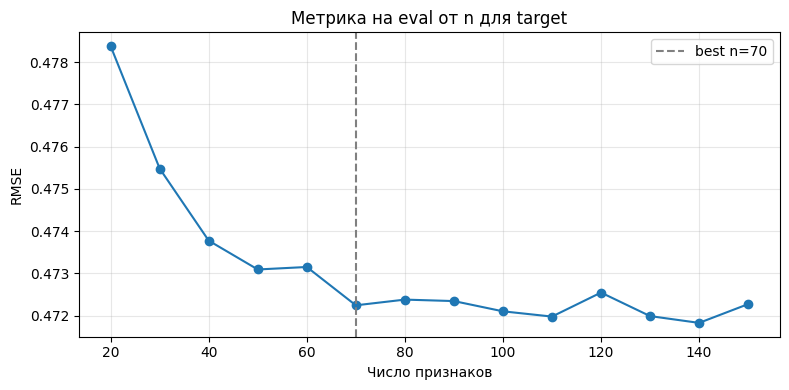

  0%|          | 0/30 [00:00<?, ?trial/s, best loss=?]

2026-05-24 21:00 INFO build_posterior_wrapper took 0.001329 seconds
2026-05-24 21:00 INFO TPE using 0 trials


  3%|▎         | 1/30 [00:06<03:13,  6.68s/trial, best loss: 0.4661977429807106]

2026-05-24 21:00 INFO build_posterior_wrapper took 0.002272 seconds
2026-05-24 21:00 INFO TPE using 1/1 trials with best loss 0.466198


  7%|▋         | 2/30 [00:11<02:39,  5.71s/trial, best loss: 0.4661977429807106]

...

 93%|█████████▎| 28/30 [01:28<00:10,  5.15s/trial, best loss: 0.46399202691233876]

2026-05-24 21:02 INFO build_posterior_wrapper took 0.002024 seconds
2026-05-24 21:02 INFO TPE using 28/28 trials with best loss 0.463992


 97%|█████████▋| 29/30 [01:34<00:05,  5.54s/trial, best loss: 0.46399202691233876]

2026-05-24 21:02 INFO build_posterior_wrapper took 0.002417 seconds
2026-05-24 21:02 INFO TPE using 29/29 trials with best loss 0.463992


100%|██████████| 30/30 [01:36<00:00,  3.22s/trial, best loss: 0.46399202691233876]
CPU times: user 29min 41s, sys: 20.5 s, total: 30min 1s
Wall time: 2min 23s


In [77]:
%%time
PRESELECTION_TOP_N = 150  # Количество предварительно отобранных фичей

results = {}

for target in [TARGET]:
    # Предварительный отбор фичей
    selected, imp, _ = select_by_importance(train[features + [target]], target, 
                                                eval_data=test[features + [target]], max_features=PRESELECTION_TOP_N)
    # Подбор оптимального количества фичей
    report_n, best_n, selected, model = metric_vs_n_features(train[selected + [target]], target, 
                                                             eval_data=test[selected + [target]], imp=imp[selected], step=10, threshold=0.001)
    # Подбор гиперпараметров
    best_model, best_params = tune_hyperparams(train[selected + [target]], target, test[selected + [target]], max_evals=30)
    report = evaluate_model(best_model, train[selected + [target]], test[selected + [target]], oot[selected + [target]], target)

    results[target] = {
        "selected": selected,
        "model": best_model,
        "evaluate_report": report,
        "best_n": best_n,
        "best_params": best_params,
        "metric_vs_n": report_n,
    }

# Сводная таблица по всем таргетам (Train/Test/OOT)
reports_all = pd.concat([results[t]["evaluate_report"] for t in [TARGET]], ignore_index=True)

In [78]:
reports_all

,Target,AVG target,AVG pred,Dataset,MAE,MAE 95%,RMSE,Non Zero
0,target,0.399918,0.392160,Train,0.275484,0.242657,0.418628,146303
1,target,0.427100,0.417640,Test,0.306834,0.271131,0.463992,13199
2,target,0.424555,0.426656,OOT,0.303764,0.280695,0.402399,14943


In [81]:
check_working_model(train, results['target']['model'].predict(train[results['target']['selected']]),
                   test, results['target']['model'].predict(test[results['target']['selected']]),
                   oot, results['target']['model'].predict(oot[results['target']['selected']]))

MAE const: 0.4280471970526455
R2 model train : 0.39773969979453094
R2 model test  : 0.29404835229704573
R2 model oot   : 0.2664056642349406


In [82]:
results['target']

{'selected': ['new_limit',
  'contract_agg_monthly_cred_pil_debt_share_aggavg_12m',
  'contract_agg_monthly_dep_total_interest_rate_aggavg_24m',
  'contract_delinquency_interval_total_overdue_principal_sum_aggmax',
  'contract_agg_monthly_cred_pil_debt_share_aggmax_6m',
  'crds_cci_agreewithpresale_aggavg_d180',
  'contract_agg_monthly_dep_card_debit_client_turn_aggavg_1m',
  'transaction_supermarkets_trans_avg_sum_12m',
  'contract_agg_monthly_dep_card_debit_turn_share_1m',
  'crds_cci_max_limit_presale_aggmin_d720',
  'client_contact_contact_by_category_home_aggcnt',
  'contract_agg_monthly_dep_total_cash_in_ofc_sum_aggsum_12m',
  'contract_cred_current_debt_amt_by_status_nm_wrk_by_product_category_nm_ptb_pil_aggsum',
  'crds_cci_instant_aggsum_d180',
  'half_posting_mpc_trx_out_sum_aggavg_m6',
  'dbo_dpasp_appl_total_cred_reject_cnt_aggsum_m3',
  'dbo_dpasp_days_from_last_trans_self',
  'crds_cci_agreewithpresale_aggsum_d720',
  'dbo_dpasp_total_trans_amt_aggavg_m3',
  'contract_agg

In [84]:
# === Срез: нулевая утилизация и сегмент y>0 ===

ZERO_EPS = 1e-9          # фактический ноль (учёт float)
THRESHOLDS = [0.03, 0.05, 0.10, 0.15, 0.20]  # пороги pred «низкая утилизация»

model = results[TARGET]["model"]
feat = results[TARGET]["selected"]


def _zero_slice_one(df, name, thresholds=THRESHOLDS):
    y = df[TARGET].astype(float).values
    pred = model.predict(df[feat])
    is_zero = y <= ZERO_EPS
    n = len(y)
    n_zero = int(is_zero.sum())
    nz = ~is_zero

    rows = []
    for t in thresholds:
        pred_low = pred < t
        tp = int((pred_low & is_zero).sum())
        fp = int((pred_low & ~is_zero).sum())
        fn = int((~pred_low & is_zero).sum())
        tn = int((~pred_low & ~is_zero).sum())
        n_pred_low = int(pred_low.sum())
        precision = tp / n_pred_low if n_pred_low > 0 else np.nan
        recall = tp / n_zero if n_zero > 0 else np.nan
        rows.append({
            "Dataset": name,
            "Порог pred": t,
            "Доля клиентов pred < порог, %": round(100 * n_pred_low / n, 2),
            "Precision (среди pred<порог — доля реальных нулей), %": round(100 * precision, 2) if pd.notna(precision) else np.nan,
            "Recall (доля пойманных нулей), %": round(100 * recall, 2) if pd.notna(recall) else np.nan,
            "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        })

    summary = pd.DataFrame(rows)

    mae_all = mean_absolute_error(y, pred)
    mae_nz = mean_absolute_error(y[nz], pred[nz]) if nz.sum() > 0 else np.nan
    mae_zero = mean_absolute_error(y[is_zero], pred[is_zero]) if n_zero > 0 else np.nan
    r2 = r2_score(y, pred)
    mae_const = mean_absolute_error(y, np.full_like(y, y.mean()))

    metrics = pd.DataFrame([{
        "Dataset": name,
        "N": n,
        "Доля факт. нулей, %": round(100 * n_zero / n, 2),
        "MAE (все)": round(mae_all, 4),
        "MAE (y=0)": round(mae_zero, 4),
        "MAE (y>0)": round(mae_nz, 4),
        "MAE const (baseline)": round(mae_const, 4),
        "R2": round(r2, 4),
        "AVG target": round(y.mean(), 4),
        "AVG pred": round(pred.mean(), 4),
    }])

    return summary, metrics


thresh_tables = []
metric_tables = []
for split_name, split_df in [("Train", train), ("Test", test), ("OOT", oot)]:
    th, mt = _zero_slice_one(split_df, split_name)
    thresh_tables.append(th)
    metric_tables.append(mt)

zero_threshold_report = pd.concat(thresh_tables, ignore_index=True)
zero_metrics_report = pd.concat(metric_tables, ignore_index=True)

print("=== Основные метрики (MAE / R²) ===")
display(zero_metrics_report)

print("\n=== Качество выделения нулевой утилизации по порогу pred ===")
print("(Precision: среди низкого прогноза — сколько реально нулей; Recall: какую долю всех нулей поймали)")
display(zero_threshold_report)

print("\n=== OOT ===")
display(zero_threshold_report[zero_threshold_report["Dataset"] == "OOT"])

# Опционально: лучший порог на OOT по F1 для класса «ноль»
oot_rows = zero_threshold_report[zero_threshold_report["Dataset"] == "OOT"].copy()
prec = oot_rows["TP"] / (oot_rows["TP"] + oot_rows["FP"]).replace(0, np.nan)
rec = oot_rows["TP"] / (oot_rows["TP"] + oot_rows["FN"]).replace(0, np.nan)
oot_rows["F1 zero, %"] = (200 * prec * rec / (prec + rec)).round(2)
best_oot = oot_rows.loc[oot_rows["F1 zero, %"].idxmax()]
print(
  f"\nНа OOT максимальный F1 по классу «ноль»: порог pred = {best_oot['Порог pred']}, "
  f"F1 = {best_oot['F1 zero, %']}%, "
  f"Recall = {best_oot['Recall (доля пойманных нулей), %']}%, "
  f"Precision = {best_oot['Precision (среди pred<порог — доля реальных нулей), %']}%"
)

=== Основные метрики (MAE / R²) ===


,Dataset,N,"Доля факт. нулей, %",MAE (все),MAE (y=0),MAE (y>0),MAE const (baseline),R2,AVG target,AVG pred
0,Train,227244,35.62,0.2755,0.2378,0.2963,0.4280,0.3977,0.3999,0.3922
1,Test,20705,36.25,0.3068,0.2669,0.3296,0.4464,0.2940,0.4271,0.4176
2,OOT,22161,32.57,0.3038,0.3016,0.3048,0.4126,0.2664,0.4246,0.4267



=== Качество выделения нулевой утилизации по порогу pred ===
(Precision: среди низкого прогноза — сколько реально нулей; Recall: какую долю всех нулей поймали)


,Dataset,Порог pred,"Доля клиентов pred < порог, %","Precision (среди pred<порог — доля реальных нулей), %","Recall (доля пойманных нулей), %",TP,FP,FN,TN
0,Train,0.03,5.17,85.84,12.46,10082,1663,70859,144640
1,Train,0.05,9.38,79.34,20.89,16905,4401,64036,141902
2,Train,0.10,18.82,68.70,36.30,29380,13385,51561,132918
3,Train,0.15,27.17,62.70,47.82,38709,23028,42232,123275
4,Train,0.20,34.62,58.66,57.02,46150,32525,34791,113778
5,Test,0.03,6.08,87.44,14.65,1100,158,6406,13041
6,Test,0.05,9.79,81.51,22.02,1653,375,5853,12824
7,Test,0.10,17.37,72.81,34.89,2619,978,4887,12221
8,Test,0.15,23.97,66.96,44.27,3323,1640,4183,11559
9,Test,0.20,30.40,62.27,52.21,3919,2375,3587,10824



=== OOT ===


,Dataset,Порог pred,"Доля клиентов pred < порог, %","Precision (среди pred<порог — доля реальных нулей), %","Recall (доля пойманных нулей), %",TP,FP,FN,TN
10,OOT,0.03,3.68,83.56,9.43,681,134,6537,14809
11,OOT,0.05,6.60,76.42,15.49,1118,345,6100,14598
12,OOT,0.10,13.36,65.00,26.66,1924,1036,5294,13907
13,OOT,0.15,20.03,57.93,35.62,2571,1867,4647,13076
14,OOT,0.20,26.73,53.64,44.01,3177,2746,4041,12197



На OOT максимальный F1 по классу «ноль»: порог pred = 0.2, F1 = 48.35%, Recall = 44.01%, Precision = 53.64%


In [86]:
ZERO_EPS = 1e-9          # фактический ноль (учёт float)
THRESHOLD_START = 0.01
THRESHOLD_END = 0.20
THRESHOLD_STEP = 0.01
THRESHOLDS = np.round(
    np.arange(THRESHOLD_START, THRESHOLD_END + THRESHOLD_STEP / 2, THRESHOLD_STEP), 2
)  # пороги pred «низкая утилизация», шаг 0.01

model = results[TARGET]["model"]
feat = results[TARGET]["selected"]


def _zero_slice_one(df, name, thresholds=THRESHOLDS):
    y = df[TARGET].astype(float).values
    pred = model.predict(df[feat])
    is_zero = y <= ZERO_EPS
    n = len(y)
    n_zero = int(is_zero.sum())
    nz = ~is_zero

    rows = []
    for t in thresholds:
        pred_low = pred < t
        tp = int((pred_low & is_zero).sum())
        fp = int((pred_low & ~is_zero).sum())
        fn = int((~pred_low & is_zero).sum())
        tn = int((~pred_low & ~is_zero).sum())
        n_pred_low = int(pred_low.sum())
        precision = tp / n_pred_low if n_pred_low > 0 else np.nan
        recall = tp / n_zero if n_zero > 0 else np.nan
        if pd.notna(precision) and pd.notna(recall) and (precision + recall) > 0:
            f1 = 2 * precision * recall / (precision + recall)
        else:
            f1 = np.nan
        rows.append({
            "Dataset": name,
            "Порог pred": t,
            "Доля клиентов pred < порог, %": round(100 * n_pred_low / n, 2),
            "Precision (среди pred<порог — доля реальных нулей), %": round(100 * precision, 2) if pd.notna(precision) else np.nan,
            "Recall (доля пойманных нулей), %": round(100 * recall, 2) if pd.notna(recall) else np.nan,
            "F1 (класс «ноль»), %": round(100 * f1, 2) if pd.notna(f1) else np.nan,
            "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        })

    summary = pd.DataFrame(rows)

    mae_all = mean_absolute_error(y, pred)
    mae_nz = mean_absolute_error(y[nz], pred[nz]) if nz.sum() > 0 else np.nan
    mae_zero = mean_absolute_error(y[is_zero], pred[is_zero]) if n_zero > 0 else np.nan
    r2 = r2_score(y, pred)
    mae_const = mean_absolute_error(y, np.full_like(y, y.mean()))

    metrics = pd.DataFrame([{
        "Dataset": name,
        "N": n,
        "Доля факт. нулей, %": round(100 * n_zero / n, 2),
        "MAE (все)": round(mae_all, 4),
        "MAE (y=0)": round(mae_zero, 4),
        "MAE (y>0)": round(mae_nz, 4),
        "MAE const (baseline)": round(mae_const, 4),
        "R2": round(r2, 4),
        "AVG target": round(y.mean(), 4),
        "AVG pred": round(pred.mean(), 4),
    }])

    return summary, metrics


thresh_tables = []
metric_tables = []
for split_name, split_df in [("Train", train), ("Test", test), ("OOT", oot)]:
    th, mt = _zero_slice_one(split_df, split_name)
    thresh_tables.append(th)
    metric_tables.append(mt)

zero_threshold_report = pd.concat(thresh_tables, ignore_index=True)
zero_metrics_report = pd.concat(metric_tables, ignore_index=True)

print("=== Основные метрики (MAE / R²) ===")
display(zero_metrics_report)

print("\n=== Качество выделения нулевой утилизации по порогу pred ===")
print("(Precision: среди низкого прогноза — сколько реально нулей; Recall: какую долю всех нулей поймали)")
display(zero_threshold_report)

print("\n=== OOT: только пороги ===")
display(zero_threshold_report[zero_threshold_report["Dataset"] == "OOT"])

# Лучший порог на OOT по F1
oot_rows = zero_threshold_report[zero_threshold_report["Dataset"] == "OOT"].copy()
f1_col = "F1 (класс «ноль»), %"
best_oot = oot_rows.loc[oot_rows[f1_col].idxmax()]
print(
    f"\nНа OOT максимальный F1 по классу «ноль»: порог pred = {best_oot['Порог pred']}, "
    f"F1 = {best_oot[f1_col]}%, "
    f"Recall = {best_oot['Recall (доля пойманных нулей), %']}%, "
    f"Precision = {best_oot['Precision (среди pred<порог — доля реальных нулей), %']}%"
)

=== Основные метрики (MAE / R²) ===


,Dataset,N,"Доля факт. нулей, %",MAE (все),MAE (y=0),MAE (y>0),MAE const (baseline),R2,AVG target,AVG pred
0,Train,227244,35.62,0.2755,0.2378,0.2963,0.4280,0.3977,0.3999,0.3922
1,Test,20705,36.25,0.3068,0.2669,0.3296,0.4464,0.2940,0.4271,0.4176
2,OOT,22161,32.57,0.3038,0.3016,0.3048,0.4126,0.2664,0.4246,0.4267



=== Качество выделения нулевой утилизации по порогу pred ===
(Precision: среди низкого прогноза — сколько реально нулей; Recall: какую долю всех нулей поймали)


,Dataset,Порог pred,"Доля клиентов pred < порог, %","Precision (среди pred<порог — доля реальных нулей), %","Recall (доля пойманных нулей), %","F1 (класс «ноль»), %",TP,FP,FN,TN
0,Train,0.01,0.61,92.17,1.59,3.12,1283,109,79658,146194
1,Train,0.02,2.76,89.73,6.95,12.90,5624,644,75317,145659
2,Train,0.03,5.17,85.84,12.46,21.76,10082,1663,70859,144640
3,Train,0.04,7.33,82.33,16.95,28.11,13716,2943,67225,143360
4,Train,0.05,9.38,79.34,20.89,33.07,16905,4401,64036,141902
5,Train,0.06,11.33,76.59,24.36,36.96,19718,6026,61223,140277
6,Train,0.07,13.27,74.25,27.66,40.31,22391,7766,58550,138537
7,Train,0.08,15.18,72.11,30.72,43.09,24867,9618,56074,136685
8,Train,0.09,17.01,70.26,33.55,45.42,27159,11494,53782,134809
9,Train,0.10,18.82,68.70,36.30,47.50,29380,13385,51561,132918



=== OOT: только пороги ===


,Dataset,Порог pred,"Доля клиентов pred < порог, %","Precision (среди pred<порог — доля реальных нулей), %","Recall (доля пойманных нулей), %","F1 (класс «ноль»), %",TP,FP,FN,TN
40,OOT,0.01,0.27,83.05,0.68,1.35,49,10,7169,14933
41,OOT,0.02,1.84,83.33,4.71,8.92,340,68,6878,14875
42,OOT,0.03,3.68,83.56,9.43,16.96,681,134,6537,14809
43,OOT,0.04,5.16,80.33,12.73,21.98,919,225,6299,14718
44,OOT,0.05,6.60,76.42,15.49,25.76,1118,345,6100,14598
45,OOT,0.06,7.96,74.08,18.09,29.08,1306,457,5912,14486
46,OOT,0.07,9.39,71.42,20.60,31.98,1487,595,5731,14348
47,OOT,0.08,10.74,68.61,22.62,34.03,1633,747,5585,14196
48,OOT,0.09,12.03,66.42,24.52,35.82,1770,895,5448,14048
49,OOT,0.10,13.36,65.00,26.66,37.81,1924,1036,5294,13907



На OOT максимальный F1 по классу «ноль»: порог pred = 0.2, F1 = 48.35%, Recall = 44.01%, Precision = 53.64%
2026-05-25 08:51:16,446 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.2b1dc8452d524f27bb771f96b83e549a/artifacts/notebook preview/notebook_2b1dc8452d524f27bb771f96b83e549a.html to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>



In [98]:
zero_metrics_report.to_excel('metrics.xlsx')
zero_threshold_report.to_excel('threshold.xlsx')

2026-05-25 09:11:29,384 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.2b1dc8452d524f27bb771f96b83e549a/artifacts/notebook preview/notebook_2b1dc8452d524f27bb771f96b83e549a.html to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>

2026-05-25 09:13:42,767 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.2b1dc8452d524f27bb771f96b83e549a/artifacts/notebook preview/notebook_2b1dc8452d524f27bb771f96b83e549a.html to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>



In [87]:
best_features = results[target]['selected']
features_sql = ','.join(f"'{f}'" for f in best_features)

engine_sb_dirkaim = oracle.create_engine_cdw(USERNAME_SB_DIRKAIM, PASSWORD_SB_DIRKAIM)
with engine_sb_dirkaim.connect() as conn:
    description_df =  pd.read_sql(f"""select * from SB_DIRKAIM.FEATURE_REGISTRY where f_name in ({features_sql})""", conn)
description_df = description_df[['f_name', 'f_desc', 'proc']]

In [88]:
description_df

,f_name,f_desc,proc
0,card_bm_off_diff_bm_on_aggmin_d180,"мин. количество дней, когда была подключена пр...",vmr_collect_feat_dm_mrk_card
1,card_is_digital_by_status_card_nm_aggmax,цифровая форма выпуска карты среди всех работа...,vmr_collect_feat_dm_mrk_card
2,card_ozc_flg_by_status_card_nm_aggmax,основная зарплатная карта среди всех работающи...,vmr_collect_feat_dm_mrk_card
3,card_package_package_uid_aggcnt_d730,кол-во оформленных пакетов за последние 730 дней,vmr_collect_feat_dm_mrk_card_package
4,card_sms_end_diff_sms_start_aggmin_d730,"мин. количество дней, когда был подключен смс-...",vmr_collect_feat_dm_mrk_card
...,...,...,...
64,transaction_supermarkets_trans_avg_sum_3m,"среднее суммы транзакций категории ""супермарке...",ema_collect_feat_dm_mrk_transaction
65,transaction_supermarkets_trans_avg_sum_6m,"среднее суммы транзакций категории ""супермарке...",ema_collect_feat_dm_mrk_transaction
66,transaction_supermarkets_trans_max_12m,"максимальное значение транзакции категории ""су...",ema_collect_feat_dm_mrk_transaction
67,transaction_total_trans_avg_sum_12m,средняя сумма транзакций за 12 месяцев,ema_collect_feat_dm_mrk_transaction


2026-05-25 08:53:36,603 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.2b1dc8452d524f27bb771f96b83e549a/artifacts/notebook preview/notebook_2b1dc8452d524f27bb771f96b83e549a.html to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>



In [89]:
# имена фичей в том же порядке, что у модели
names = model.feature_name_ or model.feature_names_in_ or feat

imp = pd.Series(model.feature_importances_, index=names).sort_values(ascending=False)
imp_df = imp.reset_index()
imp_df.columns = ["feature", "importance"]

display(imp_df)

,feature,importance
0,new_limit,1550
1,contract_delinquency_interval_total_overdue_pr...,1066
2,contract_agg_monthly_dep_total_interest_rate_a...,911
3,contract_agg_monthly_cred_pil_debt_share_aggav...,840
4,crds_cci_max_limit_presale_aggmin_d720,747
...,...,...
65,contract_cred_contract_uid_by_product_category...,122
66,contract_cred_contract_amt_by_status_nm_wrk_by...,107
67,dbo_dpasp_trans_individ_entity_cnt_aggsum_m1,105
68,contract_agg_monthly_cred_pil_debt_share_aggma...,95


2026-05-25 08:57:34,198 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.2b1dc8452d524f27bb771f96b83e549a/artifacts/notebook preview/notebook_2b1dc8452d524f27bb771f96b83e549a.html to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>

2026-05-25 08:59:17,360 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.2b1dc8452d524f27bb771f96b83e549a/artifacts/notebook preview/notebook_2b1dc8452d524f27bb771f96b83e549a.html to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>



In [99]:
df_descr = imp_df.merge(description_df, left_on='feature', right_on='f_name', how='left')[['feature', 'f_desc', 'proc', 'importance']].sort_values(by='importance', ascending=False)

In [100]:
df_descr.to_excel('imp_descr.xlsx')

2026-05-25 09:17:37,926 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.2b1dc8452d524f27bb771f96b83e549a/artifacts/notebook preview/notebook_2b1dc8452d524f27bb771f96b83e549a.html to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>

2026-05-25 09:19:20,655 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.2b1dc8452d524f27bb771f96b83e549a/artifacts/notebook preview/notebook_2b1dc8452d524f27bb771f96b83e549a.html to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>



In [101]:
def create_df(df, target, pred_col, y_pred, segment_name):
    result_df = df[PRIMARY_KEY+[target]].copy()
    result_df[pred_col] = y_pred
    result_df['segment'] = segment_name

    return result_df

In [102]:
os.makedirs(f"{PATH_MODELS_DATA}/{target}/", exist_ok=True)
best_features = results[target]['selected']
train_df = create_df(train, target, f'{target}_pred', results[target]['model'].predict(train[best_features]), 'train')
test_df = create_df(test, target, f'{target}_pred', results[target]['model'].predict(test[best_features]), 'test')
oot_df = create_df(oot, target, f'{target}_pred', results[target]['model'].predict(oot[best_features]), 'oot')

scored_df = pd.concat([train_df, test_df, oot_df], ignore_index=True)

# сохраняем train, test, oot выборки после отбора фичей и проскоренную выборку
train[PRIMARY_KEY + best_features + [target]].to_parquet(f"{PATH_MODELS_DATA}/{target}/sample_train.parquet")
test[PRIMARY_KEY + best_features + [target]].to_parquet(f"{PATH_MODELS_DATA}/{target}/sample_test.parquet")
oot[PRIMARY_KEY + best_features + [target]].to_parquet(f"{PATH_MODELS_DATA}/{target}/sample_oot.parquet")
scored_df.to_parquet(f"{PATH_MODELS_DATA}/{target}/scored_df.parquet")

2026-05-25 09:27:23,550 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.2b1dc8452d524f27bb771f96b83e549a/artifacts/notebook preview/notebook_2b1dc8452d524f27bb771f96b83e549a.html to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>



In [107]:
target = TARGET
pred_col = f"{target}_pred"
N_PER_SEGMENT = 30   # строк на каждый segment
SEED = 42

demo_parts = []
for seg in ["train", "test", "oot"]:
    part = scored_df.loc[scored_df["segment"] == seg]
    n = min(N_PER_SEGMENT, len(part))
    if n > 0:
        demo_parts.append(part.sample(n=n, random_state=SEED))

scored_df_demo = pd.concat(demo_parts, ignore_index=True)

if "error" not in scored_df_demo.columns:
    scored_df_demo["error"] = scored_df_demo[target].astype(float) - scored_df_demo[pred_col]

cols_demo = ["segment"] + PRIMARY_KEY + [target, pred_col, "error"]
scored_df_demo_view = scored_df_demo[cols_demo].round(4)

print(
    f"Случайная выборка: {len(scored_df_demo_view)} строк "
    f"({scored_df_demo_view['segment'].value_counts().to_dict()})"
)
display(scored_df_demo_view)

demo_path = f"scored_df_demo_sample.xlsx"
scored_df_demo_view.to_excel(demo_path, index=False)
print(f"Сохранено: {demo_path}")

Случайная выборка: 90 строк ({'train': 30, 'test': 30, 'oot': 30})


,segment,client_did,report_date,target,target_pred,error
0,train,20123467102,2025-02-25,1.0652,0.6369,0.4283
1,train,1151875433,2023-12-26,1.0138,0.4521,0.5617
2,train,1143540311,2025-06-23,0.9788,0.4219,0.5569
3,train,1177148639,2025-03-20,1.5569,1.0520,0.5049
4,train,1163999376,2024-10-30,0.0970,0.1127,-0.0157
...,...,...,...,...,...,...
85,oot,20148517918,2025-10-23,0.1188,0.0994,0.0195
86,oot,20142434017,2025-10-23,0.0000,0.6980,-0.6980
87,oot,20156271170,2025-10-23,0.1616,0.4979,-0.3363
88,oot,20158003224,2025-09-18,0.7305,0.2129,0.5176


Сохранено: scored_df_demo_sample.xlsx
2026-05-25 09:43:27,577 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.2b1dc8452d524f27bb771f96b83e549a/artifacts/notebook preview/notebook_2b1dc8452d524f27bb771f96b83e549a.html to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>

2026-05-25 09:45:40,271 - clearml.storage - ERROR - Exception encountered while uploading Failed uploading object /eservices-20158/eservices-20158_v1.2b1dc8452d524f27bb771f96b83e549a/artifacts/notebook preview/notebook_2b1dc8452d524f27bb771f96b83e549a.html to https://clearml-retail.run.fc.uralsibbank.ru (413): <html>
<head><title>413 Request Entity Too Large</title></head>
<body>
<center><h1>413 Request Entity Too Large</h1></center>
<hr><center>nginx</center>
</body>
</html>

## 10. Сохранение артефактов

In [ ]:
s3_secret = (await Secret.load("s3-retail")).get()

In [ ]:
ACCESS_KEY = s3_secret["access_key"]
SECRET_KEY = s3_secret["secret_key"]

In [ ]:
from minio import Minio

client = Minio(
    endpoint="10.167.8.142:9000",
    access_key=ACCESS_KEY,
    secret_key=SECRET_KEY,
    secure=False
)    

In [ ]:
def create_df(df, target, pred_col, y_pred, segment_name):
    result_df = df[PRIMARY_KEY+[target]].copy()
    result_df[pred_col] = y_pred
    result_df['segment'] = segment_name

    return result_df

all_psi = []
description_dfs = []
for target in TARGETS:
    os.makedirs(f"{PATH_MODELS_DATA}/{target}/", exist_ok=True)
    best_features = results[target]['selected']
    train_df = create_df(train, target, f'{target}_pred', results[target]['model'].predict(train[best_features]), 'train')
    test_df = create_df(test, target, f'{target}_pred', results[target]['model'].predict(test[best_features]), 'test')
    oot_df = create_df(oot, target, f'{target}_pred', results[target]['model'].predict(oot[best_features]), 'oot')
    
    scored_df = pd.concat([train_df, test_df, oot_df], ignore_index=True)
    
    # сохраняем train, test, oot выборки после отбора фичей и проскоренную выборку
    train[PRIMARY_KEY + best_features + [target]].to_parquet(f"{PATH_MODELS_DATA}/{target}/sample_train.parquet")
    test[PRIMARY_KEY + best_features + [target]].to_parquet(f"{PATH_MODELS_DATA}/{target}/sample_test.parquet")
    oot[PRIMARY_KEY + best_features + [target]].to_parquet(f"{PATH_MODELS_DATA}/{target}/sample_oot.parquet")
    scored_df.to_parquet(f"{PATH_MODELS_DATA}/{target}/scored_df.parquet")

    psi_scores = preprocessing.calculate_feat_psi(scored_df[[f'{target}_pred', 'report_date']], [f'{target}_pred'], date_col='report_date')
    psi_scores = psi_scores.rename(columns={f'{target}_pred':'PSI'})
    psi_scores['target'] = target
    all_psi.append(psi_scores)

    psi_result[best_features].T.to_excel(f'{REPORTS_FOLDER}/psi_top20_{target}.xlsx')
    
    features_sql = ','.join(f"'{f}'" for f in best_features)

    engine_sb_dirkaim = oracle.create_engine_cdw(USERNAME_SB_DIRKAIM, PASSWORD_SB_DIRKAIM)
    with engine_sb_dirkaim.connect() as conn:
        description_df =  pd.read_sql(f"""select * from SB_DIRKAIM.FEATURE_REGISTRY where f_name in ({features_sql})""", conn)
    description_df = description_df[['f_name', 'f_desc', 'proc']]
    description_df['target'] = target
    description_dfs.append(description_df)

    client.fput_object('retail', 
                       f'models/eservices-{TASK_NUM}/{SUBTASK}/{target}/train.paruqet',
                       f'{PATH_MODELS_DATA}/{target}/sample_train.parquet')
    client.fput_object('retail', 
                       f'models/eservices-{TASK_NUM}/{SUBTASK}/{target}/test.paruqet',
                       f'{PATH_MODELS_DATA}/{target}/sample_test.parquet')
    client.fput_object('retail', 
                       f'models/eservices-{TASK_NUM}/{SUBTASK}/{target}/oot.paruqet', 
                       f'{PATH_MODELS_DATA}/{target}/sample_oot.parquet')
    client.fput_object('retail', 
                       f'models/eservices-{TASK_NUM}/{SUBTASK}/{target}/scored_df.paruqet', 
                       f'{PATH_MODELS_DATA}/{target}/scored_df.parquet')

In [ ]:
psi_pred = pd.concat(all_psi, ignore_index=True)
descriptions = pd.concat(description_dfs, ignore_index=True)

## 12. Публикация модели в Model_Registry

In [ ]:
# Креды для подключения S3
s3_kwargs = (await Secret.load("s3-retail")).get()
# Пароль для работы с SB_DIRKAIM (!)
cdw_pass = (await Secret.load("pass-sb-dirkaim")).get() 


from model_repository import ModelRepository
from model_repository.dao import OracleDAO
from model_repository.storage import MinioClient

engine = oracle.create_engine_cdw(
    username="KOVALENKOVDY[SB_DIRKAIM]", password=cdw_pass
)
dao = OracleDAO(engine)
storage = MinioClient(**s3_kwargs)

# Инициализируем класс ModelRepository
repo = ModelRepository(storage=storage, dao=dao)

In [ ]:
TARGETS_CAT = [
    'supermarkets_v2_cnt_1m',
    'supermarkets_v2_sum_1m'
]

In [ ]:
import pickle
from model_repository import RegisterRequest

In [ ]:
monthYear = datetime.datetime.now().strftime('%m%y')

for target, prod in zip(TARGETS, TARGETS_CAT):
    MODEL_NAME = f"{ML_TYPE}_{prod}_{monthYear}_{SUBTASK}"
    output_file = f"{PATH_MODELS_DATA}/{target}/{MODEL_NAME}.pkl"
    with open(output_file, 'wb') as file: 
        pickle.dump(results[target]['model'], file) 
    print(MODEL_NAME)
    req = RegisterRequest(
        model_name=MODEL_NAME,
        model_type="lightgbm",  # "catboost" | "lightgbm" | "sklearn" | "other"
        artifact_format="pickle",
        uri=f"retail/models/eservices-{TASK_NUM}/{SUBTASK}/{MODEL_NAME}.pkl",
        created_by=AUTHOR,
        description="Модель предсказания суммы/количества трат в MCC категории в течение 30 дней", # Описание целевой переменной
        scoring_flg=1,  # Флаг что модель на активном скоринге
        monitoring_flg=0,  # Флаг что модель на мониторинге
        is_online=0,  # Флаг онлайн модели
        model_obj=results[target]['model'],  # авто-сериализуем, авто-извлечём важности
    )
    # Регистрируем модель
    meta = repo.register(req)
    print(meta)
    # Проверка что модель зарегистрирована
    assert repo.exists(MODEL_NAME)

In [ ]:
reports_all

In [ ]:
psi_pred

In [ ]:
descriptions

In [ ]:
with pd.ExcelWriter(f"report_{MCC_CAT}.xlsx", engine="openpyxl") as writer:
    reports_all.to_excel(writer, sheet_name="Лист1", index=False)
    psi_pred.to_excel(writer, sheet_name="Лист2", index=False)
    descriptions.to_excel(writer, sheet_name="Лист3", index=False)

In [ ]:
for i in descriptions['f_name'].unique():
    print(f'{i},')

In [ ]:
for i in descriptions['proc'].unique():
    print(f'LEFT JOIN {i} t1 on a.client_did = t1.client_did ')

In [ ]:
with engine_cdw.connect() as conn:
    df_to_score = pd.read_sql(f"""select * from ema_supermarkets_mcc""", conn)

In [ ]:
df_to_score

In [ ]:
df_out = []
for target, prod in zip(TARGETS, TARGETS_CAT):
    best_features = results[target]['selected']
    preds = results[target]['model'].predict(df_to_score[best_features])
    out_scores = df_to_score[['client_did', 'report_date']].copy()
    out_scores['score'] = preds
    out_scores['model_name'] = f"{ML_TYPE}_{prod}_{monthYear}_{SUBTASK}"
    df_out.append(out_scores)

In [ ]:
res_scored = pd.concat(df_out, axis=0, ignore_index=True)

In [ ]:
res_scored.to_parquet(f'scoring/{MCC_CAT}.parquet')